In [90]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


To access the `DFBench/DFBench_Image25` dataset, you may need to log in to Hugging Face. You can do this by running `!huggingface-cli login` in a code cell and following the instructions, or by setting the `HF_TOKEN` environment variable.

In [91]:
import os
import zipfile
import glob
from PIL import Image

# Directory for data
data_dir = './data'
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

# Download Flick8kimg.zip using the updated 'hf' command
print("Downloading Flick8kimg.zip...")
!hf download IntMeGroup/DFBench Flick8kimg.zip \
  --repo-type dataset --local-dir {data_dir}

zip_path = os.path.join(data_dir, 'Flick8kimg.zip')
extract_dir = os.path.join(data_dir, 'Flick8kimg_extracted')

# Unzip the file
if os.path.exists(zip_path):
    print(f"Unzipping {zip_path} to {extract_dir}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Unzipping complete.")
else:
    print(f"Error: {zip_path} not found. Please ensure the download was successful.")

# Verify extracted contents and prepare for image loading
# Let's dynamically find the image root directory within the extracted content
# Assuming the images are directly under the extracted directory or in a single subfolder.
image_root_dir = extract_dir
# Look for a common image subfolder if extract_dir itself doesn't contain images
# For example, if it extracts into 'Flicker8k_Dataset' or similar.
# Let's inspect the contents more robustly.

found_subfolder = False
for item in os.listdir(extract_dir):
    full_item_path = os.path.join(extract_dir, item)
    if os.path.isdir(full_item_path):
        # Check if this subfolder contains image files
        if any(f.endswith(('.jpg', '.jpeg', '.png')) for f in os.listdir(full_item_path)):
            image_root_dir = full_item_path
            found_subfolder = True
            break

if not found_subfolder:
    print(f"Warning: No obvious image subfolder found in {extract_dir}. Assuming images are directly in {extract_dir}.")


if os.path.exists(image_root_dir):
    print(f"Image dataset found at: {image_root_dir}")
    # Create a dictionary mapping relative image paths (from labels) to full system paths
    image_paths = {}
    # Adjusted glob to search directly in image_root_dir (which might be extract_dir or a subfolder)
    for img_file in glob.glob(os.path.join(image_root_dir, '*.jpg'), recursive=False):
        relative_path = os.path.relpath(img_file, image_root_dir)
        image_paths[relative_path] = img_file
    print(f"Loaded {len(image_paths)} image paths from extracted zip.")
else:
    print(f"Error: Image root directory {image_root_dir} not found after extraction. Check zip content structure.")
    image_paths = {} # Ensure it's defined even on error

# 'ds' will now hold this mapping, to be used in the next cell for loading images based on labels.
ds = image_paths

✓ Downloaded
  path: /content/data/Flick8kimg.zip
Unzipping ./data/Flick8kimg.zip to ./data/Flick8kimg_extracted...
Unzipping complete.
Image dataset found at: ./data/Flick8kimg_extracted/Images
Loaded 8091 image paths from extracted zip.


In [92]:
# Display the keys of the loaded dataset to see available splits (e.g., 'train', 'test')
print("Dataset keys:", ds.keys())

# Assuming there's a 'train' split, let's look at the first example
if 'train' in ds:
    print("\nFirst example from 'train' split:")
    print(ds['train'][0])
else:
    print("\nNo 'train' split found in the dataset.")

Dataset keys: dict_keys(['3672109677_8caa992671.jpg', '2290589734_b588471345.jpg', '463786229_b54c9a3436.jpg', '2453990033_df53f0d8c8.jpg', '544576742_283b65fa0d.jpg', '1472230829_803818a383.jpg', '2978810122_183e60ff2d.jpg', '3172283002_3c0fc624de.jpg', '3555729342_cc7a3b67fd.jpg', '2622517932_57c52c376f.jpg', '972381743_5677b420ab.jpg', '3420278866_1d17c12713.jpg', '351876121_c7c0221928.jpg', '3725814794_30db172f67.jpg', '1510669311_75330b4781.jpg', '3495349745_1b29a63571.jpg', '3306212559_731ba9bd05.jpg', '297169473_d3974e0275.jpg', '3658016590_f761e72dc3.jpg', '3075068274_2a28a5263b.jpg', '124972799_de706b6d0b.jpg', '3425851292_de92a072ee.jpg', '3316046339_8e504be038.jpg', '50030244_02cd4de372.jpg', '1348947380_14f0fc1237.jpg', '3718892835_a3e74a3417.jpg', '2224995194_518859d97d.jpg', '3444982197_0ff15cc50b.jpg', '475816542_f5c2736815.jpg', '143552829_72b6ba49d4.jpg', '2053006423_6adf69ca67.jpg', '450596617_ed37ec0fe4.jpg', '2814028429_561a215259.jpg', '2991575785_bd4868e215.jpg', 

### Inspecting Hugging Face Dataset Cards for Label Information

To find potential labeling documentation for a dataset like `DFBench/DFBench_Image25` on Hugging Face, follow these steps:

1.  **Go to the Hugging Face Datasets Hub:** Navigate to `huggingface.co/datasets` and search for the specific dataset (e.g., `DFBench/DFBench_Image25`).

2.  **Locate the 'Dataset Card' (README.md):** On the dataset's page, the primary view is usually the 'Dataset Card', which presents a `README.md` file with detailed information.

3.  **Key Sections to Review:** Within the Dataset Card, pay close attention to the following sections:
    *   **'Dataset Structure' or 'Data Fields':** This is the most crucial section. It explicitly lists all the features (columns) available in each data split (e.g., 'train', 'validation', 'test'). You would look here for a 'label' field and its description (e.g., if it's an integer representing a class, a string, etc.). For `DFBench/DFBench_Image25`, our prior inspection of this section revealed only an 'image' feature, indicating the absence of direct labels.
    *   **'Splits':** Describes how the dataset is partitioned (e.g., train, test sets) and may offer clues about expected data types or content within each split.
    *   **'Additional Information' or 'Usage':** Sometimes, dataset creators include notes on how to properly use the dataset, which might mention how to access or generate labels if they are not immediately obvious.
    *   **'Tasks & Languages' or 'Annotation':** These sections might describe the task the dataset is intended for (e.g., image classification) and details about how the data was annotated or labeled.

For `DFBench/DFBench_Image25`, the `dataset.features` inspection within the code (`ds['train'].features`) directly showed that the dataset, as loaded, only contains an `Image` feature, without an explicit `label` field. This confirms that for deepfake detection, this dataset does not inherently come with the 'real'/'fake' labels required for supervised learning.

It appears you've found the label files for the `DFBench` dataset! Let's download these files and then process them to associate the images with their respective labels. First, we'll download the files to a local `data` directory.

In [93]:
# Create a directory for the label files if it doesn't exist
import os
if not os.path.exists('./data'):
    os.makedirs('./data')

# Training labels - Using 'hf download' as 'huggingface-cli' is deprecated
!hf download IntMeGroup/DFBench img_train_shuffled.jsonl \
  --repo-type dataset --local-dir ./data

# Test labels - Using 'hf download' as 'huggingface-cli' is deprecated
!hf download IntMeGroup/DFBench img_test.jsonl \
  --repo-type dataset --local-dir ./data

print("Label files downloaded successfully to ./data/")

# Verify the contents of the data directory
print("\nVerifying contents of ./data directory:")
!ls -R ./data

✓ Downloaded
  path: /content/data/img_train_shuffled.jsonl
✓ Downloaded
  path: /content/data/img_test.jsonl
Label files downloaded successfully to ./data/

Verifying contents of ./data directory:
./data:
Flick8kimg_extracted  Flick8kimg.zip  img_test.jsonl  img_train_shuffled.jsonl

./data/Flick8kimg_extracted:
captions.txt  Images

./data/Flick8kimg_extracted/Images:
1000268201_693b08cb0e.jpg  2701487024_e866eb4550.jpg  3391209042_d2de8a8978.jpg
1001773457_577c3a7d70.jpg  2701603045_6cbdc4ce7c.jpg  3391924827_53b31542ce.jpg
1002674143_1b742ab4b8.jpg  2701895972_8605c4e038.jpg  3392019836_c7aeebca1c.jpg
1003163366_44323f5815.jpg  2702506716_17a7fb3ba4.jpg  3392293702_ccb0599857.jpg
1007129816_e794419615.jpg  270263570_3160f360d3.jpg   3392851587_a638ff25e2.jpg
1007320043_627395c3d8.jpg  2703155733_19ac6f97a8.jpg  3393035454_2d2370ffd4.jpg
1009434119_febe49276a.jpg  2704257993_d485058a5f.jpg  3393152604_27bd1037f2.jpg
1012212859_01547e3f17.jpg  2704362232_7d84503433.jpg  3393343330_b1

Now that we have the label files, let's load them using pandas and inspect their structure. We'll then need to map these labels to the images from the `DFBench/DFBench_Image25` dataset. Since the `DFBench/DFBench_Image25` dataset is already loaded (`ds` variable), we will focus on extracting the image IDs from both the image dataset and the label files to create a unified dataset.

In [94]:
from scipy.ndimage import gaussian_filter
import numpy as np
import os
from PIL import Image, ImageFilter # Ensure ImageFilter is imported for sharpening
from skimage.transform import resize # Ensure resize is imported for cropping

# --- Image Transformation Functions ---

def apply_blur(image_array, sigma=1.0):
    """Applies Gaussian blur to an image array (flattened 32x32x3) and flattens it back."""
    img_reshaped = image_array.reshape(32, 32, 3)
    blurred_img = gaussian_filter(img_reshaped, sigma=(sigma, sigma, 0), mode='nearest') # Blur each color channel independently
    return blurred_img.flatten()

def apply_compression(image_array, resize_dim=16):
    """Simulates compression by resizing down and then up. Assumes normalized [0,1] input.
    Converts to 0-255 for PIL, then back to 0-1 normalized after transformation.
    """
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    img_down = img_pil.resize((resize_dim, resize_dim), Image.LANCZOS) # Downsample
    img_up = img_down.resize((32, 32), Image.LANCZOS) # Upsample
    compressed_img = np.array(img_up).flatten() / 255.0
    return compressed_img

def apply_resize_transform(image_array, target_dim=16):
    """Resizes an image array to a target_dim and then back to 32x32, simulating a different effective resolution."
    This is similar to compression, but explicitly for 'resized' test case.
    """
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    img_small = img_pil.resize((target_dim, target_dim), Image.LANCZOS)
    img_large = img_small.resize((32, 32), Image.LANCZOS)
    resized_img = np.array(img_large).flatten() / 255.0
    return resized_img

def add_gaussian_noise(image_array, mean=0.0, std=0.1):
    """Adds Gaussian noise to an image array (flattened 32x32x3) and flattens it back."
    Assumes normalized [0,1] input and clips output to [0,1].
    """
    img_reshaped = image_array.reshape(32, 32, 3)
    noise = np.random.normal(mean, std, img_reshaped.shape)
    noisy_img = img_reshaped + noise
    noisy_img = np.clip(noisy_img, 0, 1) # Clip to maintain [0,1] range
    return noisy_img.flatten()

def apply_color_inversion(image_array):
    """Applies color inversion to an image array (flattened 32x32x3).
    Assumes normalized [0,1] input and inverts colors (1 - pixel_value).
    """
    inverted_img = 1.0 - image_array
    return inverted_img

def apply_random_crop(image_array, crop_size_range=(24, 30)):
    """Applies a random crop to the image and resizes it back to 32x32.
    Assumes normalized [0,1] input.
    """
    img_reshaped = image_array.reshape(32, 32, 3)
    h, w, c = img_reshaped.shape
    min_crop, max_crop = crop_size_range

    crop_size = np.random.randint(min_crop, max_crop + 1)

    x = np.random.randint(0, w - crop_size + 1)
    y = np.random.randint(0, h - crop_size + 1)

    cropped_img = img_reshaped[y:y+crop_size, x:x+crop_size]
    resized_cropped_img = resize(cropped_img, (32, 32), anti_aliasing=True)
    return resized_cropped_img.flatten()

def apply_brightness_change(image_array, factor):
    """Adjusts the brightness of an image array (flattened 32x32x3).
    factor > 1 makes it brighter, factor < 1 makes it darker.
    """
    brightened_img = np.clip(image_array * factor, 0, 1)
    return brightened_img

def apply_contrast_change(image_array, factor):
    """Adjusts the contrast of an image array (flattened 32x32x3).
    factor > 1 for higher contrast, factor < 1 for lower contrast.
    """
    mean_pixel = np.mean(image_array)
    contrasted_img = np.clip(mean_pixel + factor * (image_array - mean_pixel), 0, 1)
    return contrasted_img

def apply_screenshot(image_array, resize_dim=24, pixel_filter=Image.NEAREST):
    """Simulates a screenshot by resizing down and then up, using a pixelation filter."""
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    img_down = img_pil.resize((resize_dim, resize_dim), pixel_filter) # Pixelate effect
    img_up = img_down.resize((32, 32), pixel_filter) # Scale back up
    screenshot_img = np.array(img_up).flatten() / 255.0
    return screenshot_img

def apply_grayscale(image_array):
    """Converts an image array to grayscale (flattened 32x32x3) and converts it back to 3 channels."""
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    grayscale_img_pil = img_pil.convert('L').convert('RGB')
    grayscale_img = np.array(grayscale_img_pil).flatten() / 255.0
    return grayscale_img

def apply_sharpen(image_array, factor=1.5):
    """Applies a sharpening filter to an image array (flattened 32x32x3)."""
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    sharpened_img_pil = img_pil.filter(ImageFilter.SHARPEN)
    sharpened_img = np.array(sharpened_img_pil).flatten() / 255.0
    return sharpened_img

In [95]:
import pandas as pd
import json
import os
import numpy as np
from PIL import Image # Ensure Image is imported here for image processing

# Let's inspect the contents of the ./data directory to locate the files
print("Contents of ./data directory:")
for root, dirs, files in os.walk('./data'):
    level = root.replace('./data', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

current_data_path = './data'

# Load the training labels
with open(os.path.join(current_data_path, 'img_train_shuffled.jsonl'), 'r') as f:
    train_labels_data = [json.loads(line) for line in f]

# Load the test labels
with open(os.path.join(current_data_path, 'img_test.jsonl'), 'r') as f:
    test_labels_data = [json.loads(line) for line in f]

train_labels_df = pd.DataFrame(train_labels_data)
test_labels_df = pd.DataFrame(test_labels_data)

# Function to extract binary label from the 'conversations' column
def extract_binary_label(conversations_list):
    if conversations_list and isinstance(conversations_list, list):
        for conversation_entry in conversations_list:
            if conversation_entry.get('from') == 'gpt' and 'value' in conversation_entry:
                gpt_value = conversation_entry['value']

                # Check if 'value' is a list (nested structure)
                if isinstance(gpt_value, list):
                    for item in gpt_value:
                        if isinstance(item, dict) and item.get('role') == 'assistant' and 'content' in item:
                            assistant_content = item['content'].strip().lower()
                            if assistant_content == 'a': # 'A' means real
                                return 0
                            elif assistant_content == 'b': # 'B' means generated/fake
                                return 1
                # Fallback for if 'value' is directly a string (older format or different structure)
                elif isinstance(gpt_value, str):
                    value_string = gpt_value.lower()
                    value_string_cleaned = value_string.strip().strip('.,!?') # Remove common trailing punctuation

                    if value_string_cleaned.startswith('yes'): # Assuming 'yes' implies real
                        return 0  # Real
                    elif value_string_cleaned.startswith('no'): # Assuming 'no' implies fake
                        return 1  # Fake
                    elif 'real image' in value_string: # Fallback to broader checks
                        return 0  # Real
                    elif 'fake image' in value_string: # Fallback to broader checks
                        return 1  # Fake
                    elif value_string_cleaned == 'real': # Check for simple 'real' or 'fake'
                        return 0
                    elif value_string_cleaned == 'fake':
                        return 1
    return -1 # Return -1 for unparseable or missing labels

# Apply the function to create a 'label' column
train_labels_df['label'] = train_labels_df['conversations'].apply(extract_binary_label)
test_labels_df['label'] = test_labels_df['conversations'].apply(extract_binary_label)

print("Train labels DataFrame head (with extracted label):")
display(train_labels_df.head())
print("\nTest labels DataFrame head (with extracted label):")
display(test_labels_df.head())

# --- Debugging: Inspect conversations for entries with label -1 ---
print("\n--- Inspecting conversations with unextracted labels (train_labels_df) ---")
# Get a sample of conversations where the label is still -1
sample_unlabeled_train = train_labels_df[train_labels_df['label'] == -1]['conversations'].sample(min(5, len(train_labels_df[train_labels_df['label'] == -1]))) # Take up to 5 samples
for i, conv in enumerate(sample_unlabeled_train):
    print(f"Sample {i+1} (Train): {conv}")

print("\n--- Inspecting conversations with unextracted labels (test_labels_df) ---")
sample_unlabeled_test = test_labels_df[test_labels_df['label'] == -1]['conversations'].sample(min(5, len(test_labels_df[test_labels_df['label'] == -1]))) # Take up to 5 samples
for i, conv in enumerate(sample_unlabeled_test):
    print(f"Sample {i+1} (Test): {conv}")



# --- Now, we proceed to load images from the extracted Flick8k dataset and match them with labels ---

# Prepare training data
X_train_dfbench_list = []
y_train_dfbench_list = []
processed_train_count = 0

for idx, row in train_labels_df.iterrows():
    # The 'image' field in the jsonl is expected to be a relative path, e.g., 'Flick8k_Dataset/image_name.jpg'
    image_relative_path = row['image']
    label = row['label']

    if label == -1: # Skip unparseable labels
        continue

    # EXTRACT ONLY THE FILENAME to match with 'ds' keys
    image_filename = os.path.basename(image_relative_path)

    # Use the 'ds' dictionary (image_paths from previous cell) to get the full path
    if image_filename in ds:
        image_full_path = ds[image_filename]
        try:
            pil_image = Image.open(image_full_path).convert("RGB")
            img_resized = pil_image.resize((32, 32)) # Resize to 32x32
            img_array = np.array(img_resized).flatten() / 255.0 # Flatten and normalize
            X_train_dfbench_list.append(img_array)
            y_train_dfbench_list.append(label)
            processed_train_count += 1
        except Exception as e:
            print(f"Error loading image {image_full_path}: {e}")
    # else: # This warning is less critical now if the label set is larger than available images
        # print(f"Warning: Training image path '{image_relative_path}' not found in extracted dataset. Skipping.")

X_train_dfbench = np.array(X_train_dfbench_list)
y_train_dfbench = np.array(y_train_dfbench_list)

print(f"\nDFBench X_train shape (with labels): {X_train_dfbench.shape}")
print(f"DFBench y_train shape (with labels): {y_train_dfbench.shape}")
print(f"Processed {processed_train_count} training images with valid labels.")

# Prepare testing data
X_test_dfbench_list = []
y_test_dfbench_list = []
processed_test_count = 0

for idx, row in test_labels_df.iterrows():
    image_relative_path = row['image']
    label = row['label']

    if label == -1: # Skip unparseable labels
        continue

    # EXTRACT ONLY THE FILENAME to match with 'ds' keys
    image_filename = os.path.basename(image_relative_path)

    if image_filename in ds:
        image_full_path = ds[image_filename]
        try:
            pil_image = Image.open(image_full_path).convert("RGB")
            img_resized = pil_image.resize((32, 32))
            img_array = np.array(img_resized).flatten() / 255.0
            X_test_dfbench_list.append(img_array)
            y_test_dfbench_list.append(label)
            processed_test_count += 1
        except Exception as e:
            print(f"Error loading image {image_full_path}: {e}")
    # else: # This warning is less critical now if the label set is larger than available images
        # print(f"Warning: Test image path '{image_relative_path}' not found in extracted dataset. Skipping.")

X_test_dfbench = np.array(X_test_dfbench_list)
y_test_dfbench = np.array(y_test_dfbench_list)

print(f"\nDFBench X_test shape (with labels): {X_test_dfbench.shape}")
print(f"DFBench y_test shape (with labels): {y_test_dfbench.shape}")
print(f"Processed {processed_test_count} testing images with valid labels.")

print("\nSuccessfully loaded and combined DFBench images with their labels!")

Streaming output truncated to the last 5000 lines.
            2913207978_9e9624e249.jpg
            2271671533_7538ccd556.jpg
            1540631615_8b42c1b160.jpg
            3166969425_b5ace2f9c2.jpg
            531261613_f1a045cd75.jpg
            1573017288_4d481856e2.jpg
            2021613437_d99731f986.jpg
            1324816249_86600a6759.jpg
            352981175_16ff5c07e4.jpg
            481632457_7372f18275.jpg
            3048597471_5697538daf.jpg
            2245914678_1f82fc3d80.jpg
            3042484940_0975a5e486.jpg
            2823575468_15f6c345fc.jpg
            2340919359_f56787d307.jpg
            3286222970_1fa445e38f.jpg
            1089755335_0bfbfd30e6.jpg
            3458379941_657182bb09.jpg
            1467533293_a2656cc000.jpg
            3695517194_2a6b604cb2.jpg
            1280147517_98767ca3b3.jpg
            1805990081_da9cefe3a5.jpg
            2769605231_dae8b30201.jpg
            2467803152_70eeca1334.jpg
            3119696225_b289efaec8.jpg
  

,image,conversations,label
0,DFBench/kadid10k/I12_14_03.png,"[{'from': 'human', 'value': 'Is this a real im...",0
1,DFBench/ali_flux_schnell/039414.jpg,"[{'from': 'human', 'value': 'Is this a real im...",1
2,DFBench/Playground/011258.jpg,"[{'from': 'human', 'value': 'Is this a real im...",1
3,DFBench/NOVA/019792.jpg,"[{'from': 'human', 'value': 'Is this a real im...",1
4,DFBench/ali_flux_schnell/034182.jpg,"[{'from': 'human', 'value': 'Is this a real im...",1



Test labels DataFrame head (with extracted label):


,image,conversations,label
0,DFBench/Kolors/000001.jpg,"[{'from': 'human', 'value': 'Is this a real im...",1
1,DFBench/Kolors/000007.jpg,"[{'from': 'human', 'value': 'Is this a real im...",1
2,DFBench/Kolors/000012.jpg,"[{'from': 'human', 'value': 'Is this a real im...",1
3,DFBench/Kolors/000018.jpg,"[{'from': 'human', 'value': 'Is this a real im...",1
4,DFBench/Kolors/000022.jpg,"[{'from': 'human', 'value': 'Is this a real im...",1



--- Inspecting conversations with unextracted labels (train_labels_df) ---

--- Inspecting conversations with unextracted labels (test_labels_df) ---

DFBench X_train shape (with labels): (6472, 3072)
DFBench y_train shape (with labels): (6472,)
Processed 6472 training images with valid labels.

DFBench X_test shape (with labels): (1619, 3072)
DFBench y_test shape (with labels): (1619,)
Processed 1619 testing images with valid labels.

Successfully loaded and combined DFBench images with their labels!


### Applying Transformations to DFBench Test Data

We will now apply the previously defined image transformations to our `X_test_dfbench` dataset. This will allow us to assess the robustness of models trained on this dataset against various image manipulations.

In [96]:
# Apply transformations to the DFBench test set

# Blurred Images
X_test_dfbench_blurred = np.array([apply_blur(img, sigma=1.5) for img in X_test_dfbench])
print(f"Shape of DFBench blurred test data: {X_test_dfbench_blurred.shape}")

# Compressed Images
X_test_dfbench_compressed = np.array([apply_compression(img, resize_dim=16) for img in X_test_dfbench])
print(f"Shape of DFBench compressed test data: {X_test_dfbench_compressed.shape}")

# Resized Images (simulating lower resolution)
X_test_dfbench_resized = np.array([apply_resize_transform(img, target_dim=16) for img in X_test_dfbench])
print(f"Shape of DFBench resized test data: {X_test_dfbench_resized.shape}")

# Noisy Images
X_test_dfbench_noisy = np.array([add_gaussian_noise(img, std=0.2) for img in X_test_dfbench])
print(f"Shape of DFBench noisy test data: {X_test_dfbench_noisy.shape}")

Shape of DFBench blurred test data: (1619, 3072)
Shape of DFBench compressed test data: (1619, 3072)
Shape of DFBench resized test data: (1619, 3072)
Shape of DFBench noisy test data: (1619, 3072)


In [97]:
# Inverted Images
X_test_dfbench_inverted = np.array([apply_color_inversion(img) for img in X_test_dfbench])
print(f"Shape of DFBench inverted test data: {X_test_dfbench_inverted.shape}")

Shape of DFBench inverted test data: (1619, 3072)


In [98]:
# Cropped Images
X_test_dfbench_cropped = np.array([apply_random_crop(img) for img in X_test_dfbench])
print(f"Shape of DFBench cropped test data: {X_test_dfbench_cropped.shape}")

# Brighter Images
X_test_dfbench_brighter = np.array([apply_brightness_change(img, factor=1.5) for img in X_test_dfbench])
print(f"Shape of DFBench brighter test data: {X_test_dfbench_brighter.shape}")

# Darker Images
X_test_dfbench_darker = np.array([apply_brightness_change(img, factor=0.5) for img in X_test_dfbench])
print(f"Shape of DFBench darker test data: {X_test_dfbench_darker.shape}")

# Higher Contrast Images
X_test_dfbench_higher_contrast = np.array([apply_contrast_change(img, factor=1.5) for img in X_test_dfbench])
print(f"Shape of DFBench higher contrast test data: {X_test_dfbench_higher_contrast.shape}")

# Lower Contrast Images
X_test_dfbench_lower_contrast = np.array([apply_contrast_change(img, factor=0.5) for img in X_test_dfbench])
print(f"Shape of DFBench lower contrast test data: {X_test_dfbench_lower_contrast.shape}")

Shape of DFBench cropped test data: (1619, 3072)
Shape of DFBench brighter test data: (1619, 3072)
Shape of DFBench darker test data: (1619, 3072)
Shape of DFBench higher contrast test data: (1619, 3072)
Shape of DFBench lower contrast test data: (1619, 3072)


In [99]:
# Apply new social media-like transformations to the DFBench test set

# Screenshot-like Images
X_test_dfbench_screenshot = np.array([apply_screenshot(img) for img in X_test_dfbench])
print(f"Shape of DFBench screenshot test data: {X_test_dfbench_screenshot.shape}")

# Grayscale Images
X_test_dfbench_grayscale = np.array([apply_grayscale(img) for img in X_test_dfbench])
print(f"Shape of DFBench grayscale test data: {X_test_dfbench_grayscale.shape}")

# Sharpened Images
X_test_dfbench_sharpened = np.array([apply_sharpen(img) for img in X_test_dfbench])
print(f"Shape of DFBench sharpened test data: {X_test_dfbench_sharpened.shape}")

Shape of DFBench screenshot test data: (1619, 3072)
Shape of DFBench grayscale test data: (1619, 3072)
Shape of DFBench sharpened test data: (1619, 3072)


In [100]:
import numpy as np
import os
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [101]:
from skimage.transform import resize

In [102]:
real_path = "/content/drive/MyDrive/dataset/real"
fake_path = "/content/drive/MyDrive/dataset/fake"

First, we need to extract the dataset from the `archive.zip` file. This will create the `dataset` directory with the `real` and `fake` image subfolders.

In [103]:
# Unzip the dataset if it hasn't been unzipped already
archive_path = "/content/drive/MyDrive/archive.zip"
extraction_path = "/content/dataset"

import zipfile
import os

if not os.path.exists(extraction_path):
    os.makedirs(extraction_path)
    with zipfile.ZipFile(archive_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f"Dataset extracted to {extraction_path}")
else:
    print(f"Dataset already exists at {extraction_path}, skipping extraction.")

# Update the paths to reflect the extracted dataset location
# Correcting the path to assume 'real' and 'fake' are directly inside extraction_path
real_path = os.path.join(extraction_path, "real")
fake_path = os.path.join(extraction_path, "fake")

print(f"Real images path: {real_path}")
print(f"Fake images path: {fake_path}")

Dataset already exists at /content/dataset, skipping extraction.
Real images path: /content/dataset/real
Fake images path: /content/dataset/fake


Now that the dataset is extracted, we can load the images and preprocess them as you specified.

In [104]:
data = []
labels = []

# Ensure the directories exist before listing files
if not os.path.exists(real_path):
    print(f"Error: Real images directory not found at {real_path}")
else:
    real_files = os.listdir(real_path)[:5000]
    for file in real_files:
        try:
            img = Image.open(os.path.join(real_path, file)).convert("RGB")
            img = img.resize((32, 32))
            img = np.array(img).flatten() / 255.0
            data.append(img)
            labels.append(0)
        except Exception as e:
            print(f"Error loading real image {file}: {e}")

if not os.path.exists(fake_path):
    print(f"Error: Fake images directory not found at {fake_path}")
else:
    fake_files = os.listdir(fake_path)[:5000]
    for file in fake_files:
        try:
            img = Image.open(os.path.join(fake_path, file)).convert("RGB")
            img = img.resize((32, 32))
            img = np.array(img).flatten() / 255.0
            data.append(img)
            labels.append(1)
        except Exception as e:
            print(f"Error loading fake image {file}: {e}")

X = np.array(data)
y = np.array(labels)

print("Data shape:", X.shape)
print("Labels shape:", y.shape)

Error: Real images directory not found at /content/dataset/real
Error: Fake images directory not found at /content/dataset/fake
Data shape: (0,)
Labels shape: (0,)


In [105]:
print("Contents of extraction_path:")
print(os.listdir(extraction_path))

# Assuming the zip file extracts into a single subfolder, e.g., 'dataset'
# Let's find that subfolder
subdirs = [name for name in os.listdir(extraction_path) if os.path.isdir(os.path.join(extraction_path, name))]

if subdirs:
    dataset_root_folder = os.path.join(extraction_path, subdirs[0])
    print(f"Detected dataset root folder: {dataset_root_folder}")
    print(f"Contents of dataset_root_folder ({dataset_root_folder}):")
    print(os.listdir(dataset_root_folder))

    # Check contents of the 'Train' subfolder
    train_folder = os.path.join(dataset_root_folder, "Train")
    if os.path.exists(train_folder):
        print(f"Contents of {train_folder}:")
        print(os.listdir(train_folder))

    # Now, update real_path and fake_path based on this detected root folder
    # Correcting 'real' and 'fake' to 'Real' and 'Fake' based on the directory listing
    real_path = os.path.join(dataset_root_folder, "Train", "Real")
    fake_path = os.path.join(dataset_root_folder, "Train", "Fake")

    print(f"Updated real images path: {real_path}")
    print(f"Updated fake images path: {fake_path}")
else:
    print("No subdirectories found in the extraction path. Please check the zip file structure.")

Contents of extraction_path:
['Dataset']
Detected dataset root folder: /content/dataset/Dataset
Contents of dataset_root_folder (/content/dataset/Dataset):
['Validation', 'Test', 'Train']
Contents of /content/dataset/Dataset/Train:
['Real', 'Fake']
Updated real images path: /content/dataset/Dataset/Train/Real
Updated fake images path: /content/dataset/Dataset/Train/Fake


After correcting the paths, we can re-run the image loading cell.

In [106]:
import os # Added for robustness
import numpy as np # Added for robustness
from PIL import Image # Added for robustness
from sklearn.model_selection import train_test_split # Added for robustness

data = []
labels = []

# Ensure the directories exist before listing files with corrected paths
if not os.path.exists(real_path):
    print(f"Error: Real images directory not found at {real_path}")
else:
    real_files = os.listdir(real_path)[:5000]
    for file in real_files:
        try:
            img = Image.open(os.path.join(real_path, file)).convert("RGB")
            img = img.resize((32, 32))
            img = np.array(img).flatten() / 255.0
            data.append(img)
            labels.append(0)
        except Exception as e:
            print(f"Error loading real image {file}: {e}")

if not os.path.exists(fake_path):
    print(f"Error: Fake images directory not found at {fake_path}")
else:
    fake_files = os.listdir(fake_path)[:5000]
    for file in fake_files:
        try:
            img = Image.open(os.path.join(fake_path, file)).convert("RGB")
            img = img.resize((32, 32))
            img = np.array(img).flatten() / 255.0
            data.append(img)
            labels.append(1)
        except Exception as e:
            print(f"Error loading fake image {file}: {e}")

X = np.array(data)
y = np.array(labels)

print("Data shape:", X.shape)
print("Labels shape:", y.shape)

# Now that X and y are defined, split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data: ", X_train.shape)
print("Testing data: ", X_test.shape)

Data shape: (10000, 3072)
Labels shape: (10000,)
Training data:  (8000, 3072)
Testing data:  (2000, 3072)


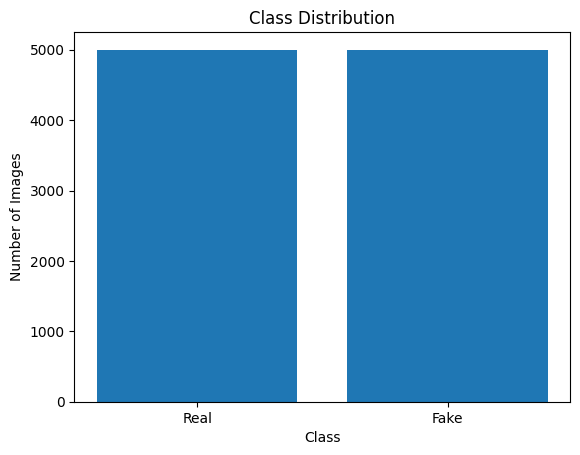

In [107]:
plt.bar(["Real", "Fake"], [sum(y == 0), sum(y == 1)])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

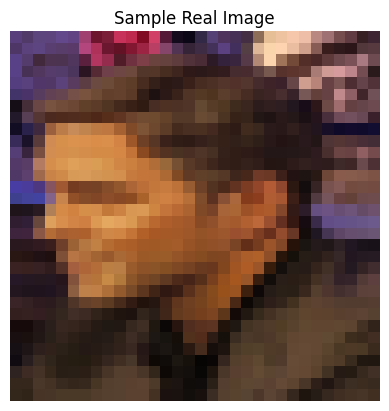

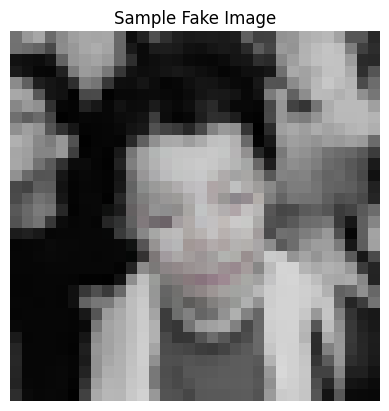

In [108]:
plt.imshow(X[0].reshape(32, 32, 3))
plt.title("Sample Real Image")
plt.axis("off")
plt.show()

plt.imshow(X[5000].reshape(32, 32, 3))
plt.title("Sample Fake Image")
plt.axis("off")
plt.show()

### Image Transformation Functions

Now, let's define helper functions to apply various transformations (blur, simulated compression, resizing, and noise) to our image data. These transformations will be applied to the test set to evaluate model robustness.

In [109]:
from scipy.ndimage import gaussian_filter
import numpy as np
import os
from PIL import Image, ImageFilter # Ensure ImageFilter is imported for sharpening
from skimage.transform import resize # Ensure resize is imported for cropping

# --- Image Transformation Functions ---

def apply_blur(image_array, sigma=1.0):
    """Applies Gaussian blur to an image array (flattened 32x32x3) and flattens it back."""
    img_reshaped = image_array.reshape(32, 32, 3)
    blurred_img = gaussian_filter(img_reshaped, sigma=(sigma, sigma, 0), mode='nearest') # Blur each color channel independently
    return blurred_img.flatten()

def apply_compression(image_array, resize_dim=16):
    """Simulates compression by resizing down and then up. Assumes normalized [0,1] input.
    Converts to 0-255 for PIL, then back to 0-1 normalized after transformation.
    """
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    img_down = img_pil.resize((resize_dim, resize_dim), Image.LANCZOS) # Downsample
    img_up = img_down.resize((32, 32), Image.LANCZOS) # Upsample
    compressed_img = np.array(img_up).flatten() / 255.0
    return compressed_img

def apply_resize_transform(image_array, target_dim=16):
    """Resizes an image array to a target_dim and then back to 32x32, simulating a different effective resolution."
    This is similar to compression, but explicitly for 'resized' test case.
    """
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    img_small = img_pil.resize((target_dim, target_dim), Image.LANCZOS)
    img_large = img_small.resize((32, 32), Image.LANCZOS)
    resized_img = np.array(img_large).flatten() / 255.0
    return resized_img

def add_gaussian_noise(image_array, mean=0.0, std=0.1):
    """Adds Gaussian noise to an image array (flattened 32x32x3) and flattens it back."
    Assumes normalized [0,1] input and clips output to [0,1].
    """
    img_reshaped = image_array.reshape(32, 32, 3)
    noise = np.random.normal(mean, std, img_reshaped.shape)
    noisy_img = img_reshaped + noise
    noisy_img = np.clip(noisy_img, 0, 1) # Clip to maintain [0,1] range
    return noisy_img.flatten()

def apply_color_inversion(image_array):
    """Applies color inversion to an image array (flattened 32x32x3).
    Assumes normalized [0,1] input and inverts colors (1 - pixel_value).
    """
    inverted_img = 1.0 - image_array
    return inverted_img

def apply_random_crop(image_array, crop_size_range=(24, 30)):
    """Applies a random crop to the image and resizes it back to 32x32.
    Assumes normalized [0,1] input.
    """
    img_reshaped = image_array.reshape(32, 32, 3)
    h, w, c = img_reshaped.shape
    min_crop, max_crop = crop_size_range

    crop_size = np.random.randint(min_crop, max_crop + 1)

    x = np.random.randint(0, w - crop_size + 1)
    y = np.random.randint(0, h - crop_size + 1)

    cropped_img = img_reshaped[y:y+crop_size, x:x+crop_size]
    resized_cropped_img = resize(cropped_img, (32, 32), anti_aliasing=True)
    return resized_cropped_img.flatten()

def apply_brightness_change(image_array, factor):
    """Adjusts the brightness of an image array (flattened 32x32x3).
    factor > 1 makes it brighter, factor < 1 makes it darker.
    """
    brightened_img = np.clip(image_array * factor, 0, 1)
    return brightened_img

def apply_contrast_change(image_array, factor):
    """Adjusts the contrast of an image array (flattened 32x32x3).
    factor > 1 for higher contrast, factor < 1 for lower contrast.
    """
    mean_pixel = np.mean(image_array)
    contrasted_img = np.clip(mean_pixel + factor * (image_array - mean_pixel), 0, 1)
    return contrasted_img

def apply_screenshot(image_array, resize_dim=24, pixel_filter=Image.NEAREST):
    """Simulates a screenshot by resizing down and then up, using a pixelation filter."""
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    img_down = img_pil.resize((resize_dim, resize_dim), pixel_filter) # Pixelate effect
    img_up = img_down.resize((32, 32), pixel_filter) # Scale back up
    screenshot_img = np.array(img_up).flatten() / 255.0
    return screenshot_img

def apply_grayscale(image_array):
    """Converts an image array to grayscale (flattened 32x32x3) and converts it back to 3 channels."""
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    grayscale_img_pil = img_pil.convert('L').convert('RGB')
    grayscale_img = np.array(grayscale_img_pil).flatten() / 255.0
    return grayscale_img

def apply_sharpen(image_array, factor=1.5):
    """Applies a sharpening filter to an image array (flattened 32x32x3)."""
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    sharpened_img_pil = img_pil.filter(ImageFilter.SHARPEN)
    sharpened_img = np.array(sharpened_img_pil).flatten() / 255.0
    return sharpened_img

### Applying Transformations to DFBench Test Data

We will now apply the previously defined image transformations to our `X_test_dfbench` dataset. This will allow us to assess the robustness of models trained on this dataset against various image manipulations.

In [110]:
# Apply transformations to the DFBench test set

# Blurred Images
X_test_dfbench_blurred = np.array([apply_blur(img, sigma=1.5) for img in X_test_dfbench])
print(f"Shape of DFBench blurred test data: {X_test_dfbench_blurred.shape}")

# Compressed Images
X_test_dfbench_compressed = np.array([apply_compression(img, resize_dim=16) for img in X_test_dfbench])
print(f"Shape of DFBench compressed test data: {X_test_dfbench_compressed.shape}")

# Resized Images (simulating lower resolution)
X_test_dfbench_resized = np.array([apply_resize_transform(img, target_dim=16) for img in X_test_dfbench])
print(f"Shape of DFBench resized test data: {X_test_dfbench_resized.shape}")

# Noisy Images
X_test_dfbench_noisy = np.array([add_gaussian_noise(img, std=0.2) for img in X_test_dfbench])
print(f"Shape of DFBench noisy test data: {X_test_dfbench_noisy.shape}")

Shape of DFBench blurred test data: (1619, 3072)
Shape of DFBench compressed test data: (1619, 3072)
Shape of DFBench resized test data: (1619, 3072)
Shape of DFBench noisy test data: (1619, 3072)


In [111]:
# Inverted Images
X_test_dfbench_inverted = np.array([apply_color_inversion(img) for img in X_test_dfbench])
print(f"Shape of DFBench inverted test data: {X_test_dfbench_inverted.shape}")

Shape of DFBench inverted test data: (1619, 3072)


In [112]:
# Cropped Images
X_test_dfbench_cropped = np.array([apply_random_crop(img) for img in X_test_dfbench])
print(f"Shape of DFBench cropped test data: {X_test_dfbench_cropped.shape}")

# Brighter Images
X_test_dfbench_brighter = np.array([apply_brightness_change(img, factor=1.5) for img in X_test_dfbench])
print(f"Shape of DFBench brighter test data: {X_test_dfbench_brighter.shape}")

# Darker Images
X_test_dfbench_darker = np.array([apply_brightness_change(img, factor=0.5) for img in X_test_dfbench])
print(f"Shape of DFBench darker test data: {X_test_dfbench_darker.shape}")

# Higher Contrast Images
X_test_dfbench_higher_contrast = np.array([apply_contrast_change(img, factor=1.5) for img in X_test_dfbench])
print(f"Shape of DFBench higher contrast test data: {X_test_dfbench_higher_contrast.shape}")

# Lower Contrast Images
X_test_dfbench_lower_contrast = np.array([apply_contrast_change(img, factor=0.5) for img in X_test_dfbench])
print(f"Shape of DFBench lower contrast test data: {X_test_dfbench_lower_contrast.shape}")

Shape of DFBench cropped test data: (1619, 3072)
Shape of DFBench brighter test data: (1619, 3072)
Shape of DFBench darker test data: (1619, 3072)
Shape of DFBench higher contrast test data: (1619, 3072)
Shape of DFBench lower contrast test data: (1619, 3072)


In [113]:
# Apply new social media-like transformations to the DFBench test set

# Screenshot-like Images
X_test_dfbench_screenshot = np.array([apply_screenshot(img) for img in X_test_dfbench])
print(f"Shape of DFBench screenshot test data: {X_test_dfbench_screenshot.shape}")

# Grayscale Images
X_test_dfbench_grayscale = np.array([apply_grayscale(img) for img in X_test_dfbench])
print(f"Shape of DFBench grayscale test data: {X_test_dfbench_grayscale.shape}")

# Sharpened Images
X_test_dfbench_sharpened = np.array([apply_sharpen(img) for img in X_test_dfbench])
print(f"Shape of DFBench sharpened test data: {X_test_dfbench_sharpened.shape}")

Shape of DFBench screenshot test data: (1619, 3072)
Shape of DFBench grayscale test data: (1619, 3072)
Shape of DFBench sharpened test data: (1619, 3072)


### Visualize Transformed DFBench Images

Let's visualize some of the transformed images from the DFBench dataset to understand the effect of each transformation.

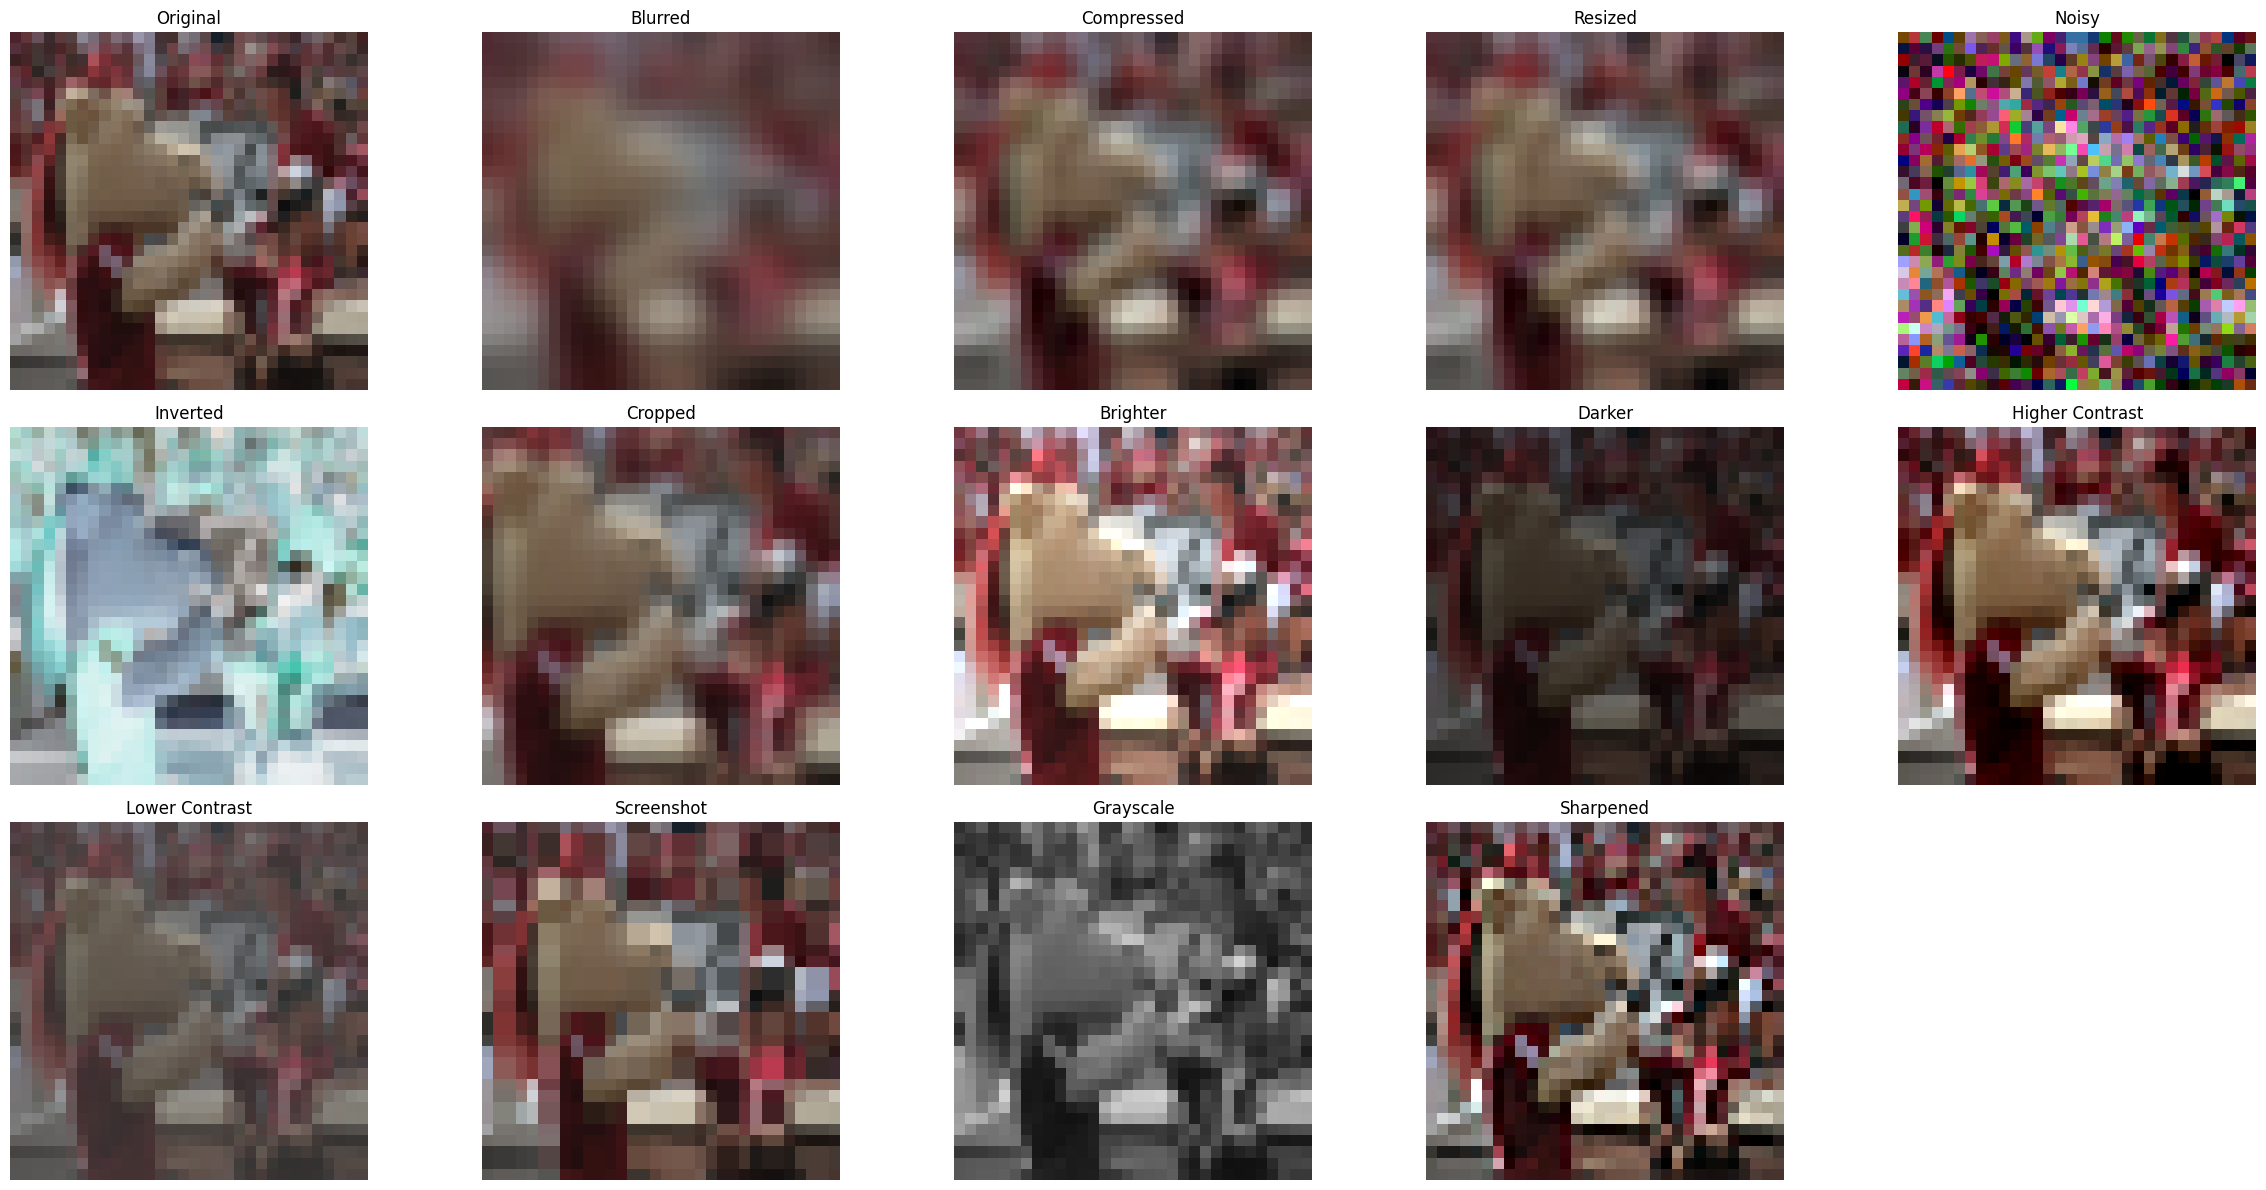

In [114]:
def plot_transformed_dfbench_images(original, blurred, compressed, resized, noisy, inverted, cropped, brighter, darker, higher_contrast, lower_contrast, screenshot, grayscale, sharpened, index=0):
    plt.figure(figsize=(24, 12))

    titles = [
        "Original", "Blurred", "Compressed", "Resized", "Noisy", "Inverted",
        "Cropped", "Brighter", "Darker", "Higher Contrast", "Lower Contrast",
        "Screenshot", "Grayscale", "Sharpened"
    ]
    images = [
        original[index], blurred[index], compressed[index], resized[index], noisy[index], inverted[index],
        cropped[index], brighter[index], darker[index], higher_contrast[index], lower_contrast[index],
        screenshot[index], grayscale[index], sharpened[index]
    ]

    for i, (title, img_data) in enumerate(zip(titles, images)):
        plt.subplot(3, 5, i + 1) # Arrange in 3 rows, 5 columns (or adjust as needed for more images)
        plt.imshow(img_data.reshape(32, 32, 3))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot a sample image with all transformations applied
plot_transformed_dfbench_images(
    X_test_dfbench, X_test_dfbench_blurred, X_test_dfbench_compressed, X_test_dfbench_resized, X_test_dfbench_noisy, X_test_dfbench_inverted,
    X_test_dfbench_cropped, X_test_dfbench_brighter, X_test_dfbench_darker, X_test_dfbench_higher_contrast, X_test_dfbench_lower_contrast,
    X_test_dfbench_screenshot, X_test_dfbench_grayscale, X_test_dfbench_sharpened,
    index=10 # Choose an index to visualize a specific image
)

### Evaluate Models on Transformed DFBench Images

Now, we will evaluate the performance of our models on the `DFBench` dataset with all applied transformations to assess their robustness.

In [115]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Initialize and train Logistic Regression and Random Forest models if not already defined
# This ensures that lr and rf are available for prediction in this cell.
if 'X_train' in globals() and 'y_train' in globals():
    if 'lr' not in globals() or not hasattr(lr, 'predict'):
        print("Training Logistic Regression model...")
        lr = LogisticRegression(max_iter=1000)
        lr.fit(X_train, y_train)

    if 'rf' not in globals() or not hasattr(rf, 'predict'):
        print("Training Random Forest model...")
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X_train, y_train)
else:
    print("Warning: X_train or y_train not found. Logistic Regression and Random Forest models will not be trained for DFBench evaluation.")

# Initialize transformed_X_tests_dfbench with all available transformed DFBench data
transformed_X_tests_dfbench = {
    "Original": X_test_dfbench,
    "Blurred": X_test_dfbench_blurred,
    "Compressed": X_test_dfbench_compressed,
    "Resized": X_test_dfbench_resized,
    "Noisy": X_test_dfbench_noisy,
    "Inverted": X_test_dfbench_inverted,
    "Cropped": X_test_dfbench_cropped,
    "Brighter": X_test_dfbench_brighter,
    "Darker": X_test_dfbench_darker,
    "Higher Contrast": X_test_dfbench_higher_contrast,
    "Lower Contrast": X_test_dfbench_lower_contrast,
    "Screenshot": X_test_dfbench_screenshot,
    "Grayscale": X_test_dfbench_grayscale,
    "Sharpened": X_test_dfbench_sharpened
}

# Initialize the results dictionary for DFBench evaluation
results_dfbench = {
    "Logistic Regression": {},
    "Random Forest": {},
    "DeepGuard (CNN)": {},
    "Hive AI (CNN)": {},
    "SID-set (CNN)": {}
}

# --- Populate results for Logistic Regression on DFBench ---
for name, transformed_X in transformed_X_tests_dfbench.items():
    if 'lr' in globals() and hasattr(lr, 'predict'):
        y_pred_lr_transformed = lr.predict(transformed_X)
        results_dfbench["Logistic Regression"][name] = accuracy_score(y_test_dfbench, y_pred_lr_transformed)
    else:
        results_dfbench["Logistic Regression"][name] = 0.0 # Placeholder if model is not available

# --- Populate results for Random Forest on DFBench ---
for name, transformed_X in transformed_X_tests_dfbench.items():
    if 'rf' in globals() and hasattr(rf, 'predict'):
        y_pred_rf_transformed = rf.predict(transformed_X)
        results_dfbench["Random Forest"][name] = accuracy_score(y_test_dfbench, y_pred_rf_transformed)
    else:
        results_dfbench["Random Forest"][name] = 0.0 # Placeholder if model is not available

# Prepare reshaped transformed test data for CNNs on DFBench
transformed_X_tests_dfbench_cnn = {}
for name, X_transformed in transformed_X_tests_dfbench.items():
    transformed_X_tests_dfbench_cnn[name] = X_transformed.reshape(-1, 32, 32, 3)

# --- Populate results for DeepGuard (CNN) on DFBench ---
for name, transformed_X_cnn in transformed_X_tests_dfbench_cnn.items():
    if 'model' in globals(): # Check if the CNN model is defined
        y_pred_cnn_proba_transformed = model.predict(transformed_X_cnn)
        y_pred_cnn_transformed = (y_pred_cnn_proba_transformed > 0.5).astype(int).flatten()
        accuracy = accuracy_score(y_test_dfbench, y_pred_cnn_transformed)
        results_dfbench["DeepGuard (CNN)"][name] = accuracy
    else:
        print(f"Warning: CNN model (DeepGuard) not found. DeepGuard (CNN) results for '{name}' will be 0.")
        results_dfbench["DeepGuard (CNN)"][name] = 0.0 # Placeholder if model is not available

# --- Populate results for Hive AI (CNN) on DFBench ---
for name, transformed_X_cnn in transformed_X_tests_dfbench_cnn.items():
    if 'hiveai_model' in globals(): # Check if the Hive AI CNN model is defined
        y_pred_hiveai_cnn_proba_transformed = hiveai_model.predict(transformed_X_cnn)
        y_pred_hiveai_cnn_transformed = (y_pred_hiveai_cnn_proba_transformed > 0.5).astype(int).flatten()
        accuracy = accuracy_score(y_test_dfbench, y_pred_hiveai_cnn_transformed)
        results_dfbench["Hive AI (CNN)"][name] = accuracy
    else:
        print(f"Warning: Hive AI (CNN) model not found. Hive AI (CNN) results for '{name}' will be 0.")
        results_dfbench["Hive AI (CNN)"][name] = 0.0 # Placeholder if model is not available

# --- Populate results for SID-set (CNN) on DFBench ---
for name, transformed_X_cnn in transformed_X_tests_dfbench_cnn.items():
    if 'sidset_model' in globals(): # Check if the SID-set CNN model is defined
        y_pred_sidset_cnn_proba_transformed = sidset_model.predict(transformed_X_cnn)
        y_pred_sidset_cnn_transformed = (y_pred_sidset_cnn_proba_transformed > 0.5).astype(int).flatten()
        accuracy = accuracy_score(y_test_dfbench, y_pred_sidset_cnn_transformed)
    else:
        print(f"Warning: SID-set (CNN) model not found. SID-set (CNN) results for '{name}' will be 0.")
        results_dfbench["SID-set (CNN)"][name] = 0.0 # Placeholder if model is not available

# Create and display results in a DataFrame
results_dfbench_df = pd.DataFrame(results_dfbench).T
display(results_dfbench_df)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


,Original,Blurred,Compressed,Resized,Noisy,Inverted,Cropped,Brighter,Darker,Higher Contrast,Lower Contrast,Screenshot,Grayscale,Sharpened
Logistic Regression,0.512662,0.575046,0.534898,0.534898,0.518221,0.520692,0.525633,0.492897,0.638666,0.505868,0.537986,0.524398,0.536751,0.498456
Random Forest,0.686844,0.663990,0.675108,0.675108,0.658431,0.673255,0.655343,0.642372,0.739963,0.613342,0.735639,0.689314,0.739345,0.680667
DeepGuard (CNN),0.767140,0.648548,0.705991,0.705991,0.847437,0.756640,0.711550,0.733169,0.837554,0.779494,0.731316,0.746140,0.772082,0.819642
Hive AI (CNN),0.738110,0.555899,0.642372,0.642372,0.836319,0.759728,0.645460,0.735639,0.767140,0.765905,0.715256,0.733169,0.764052,0.803582
SID-set (CNN),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Visualize Performance on Transformed DFBench Images

Dataset already exists at /content/dataset, skipping extraction.
Updated real images path: /content/dataset/Dataset/Train/Real
Updated fake images path: /content/dataset/Dataset/Train/Fake
---> Step 1: Load and split original data (from cell 8da9ec70) <---
Data shape: (10000, 3072)
Labels shape: (10000,)
Training data:  (8000, 3072)
Testing data:  (2000, 3072)

---> Step 2: Train Logistic Regression <---
Logistic Regression Accuracy on Original Test Data: 0.7515

---> Step 3: Train Random Forest <---
Random Forest Accuracy on Original Test Data: 0.7365

---> Step 4: Prepare data for CNNs <---
Reshaped X_train for CNN: (8000, 32, 32, 3)
Reshaped X_test for CNN: (2000, 32, 32, 3)

---> Step 5: Define and Train DeepGuard (CNN) <---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
DeepGuard (CNN) Accuracy on Original Test Data: 0.814

---> Step 6: Define and Train Hive AI (CNN) <---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Hive AI (CNN) Accuracy on Original Test Data: 0.8185

---> Step 7: Define and Train SID-set (CNN) <---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
SID-set (CNN) Accuracy on Original Test Data: 0.821

---> Step 8: Apply transformations to DFBench Test Data <---
All 13 transformations applied to test data.

---> Step 9: Evaluate Models on Transformed Data <---
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━

,Original,Blurred,Compressed,Resized,Noisy,Inverted,Cropped,Brighter,Darker,Higher Contrast,Lower Contrast,Screenshot,Grayscale,Sharpened
Logistic Regression,0.512662,0.575046,0.534898,0.534898,0.529339,0.520692,0.544781,0.492897,0.638666,0.505868,0.537986,0.524398,0.536751,0.498456
Random Forest,0.686844,0.663990,0.675108,0.675108,0.657813,0.673255,0.661519,0.642372,0.739963,0.613342,0.735639,0.689314,0.739345,0.680667
DeepGuard (CNN),0.695491,0.502162,0.604694,0.604694,0.755405,0.682520,0.630019,0.678196,0.726374,0.708462,0.646695,0.651637,0.693638,0.751081
Hive AI (CNN),0.625695,0.405188,0.528721,0.528721,0.738110,0.564546,0.563311,0.624460,0.630636,0.666461,0.521927,0.640519,0.615195,0.698579
SID-set (CNN),0.560222,0.374305,0.474985,0.474985,0.578752,0.528104,0.507721,0.557752,0.526868,0.581223,0.460778,0.557752,0.554663,0.625695



---> Step 10: Visualize Results <---


<Figure size 2200x1000 with 0 Axes>

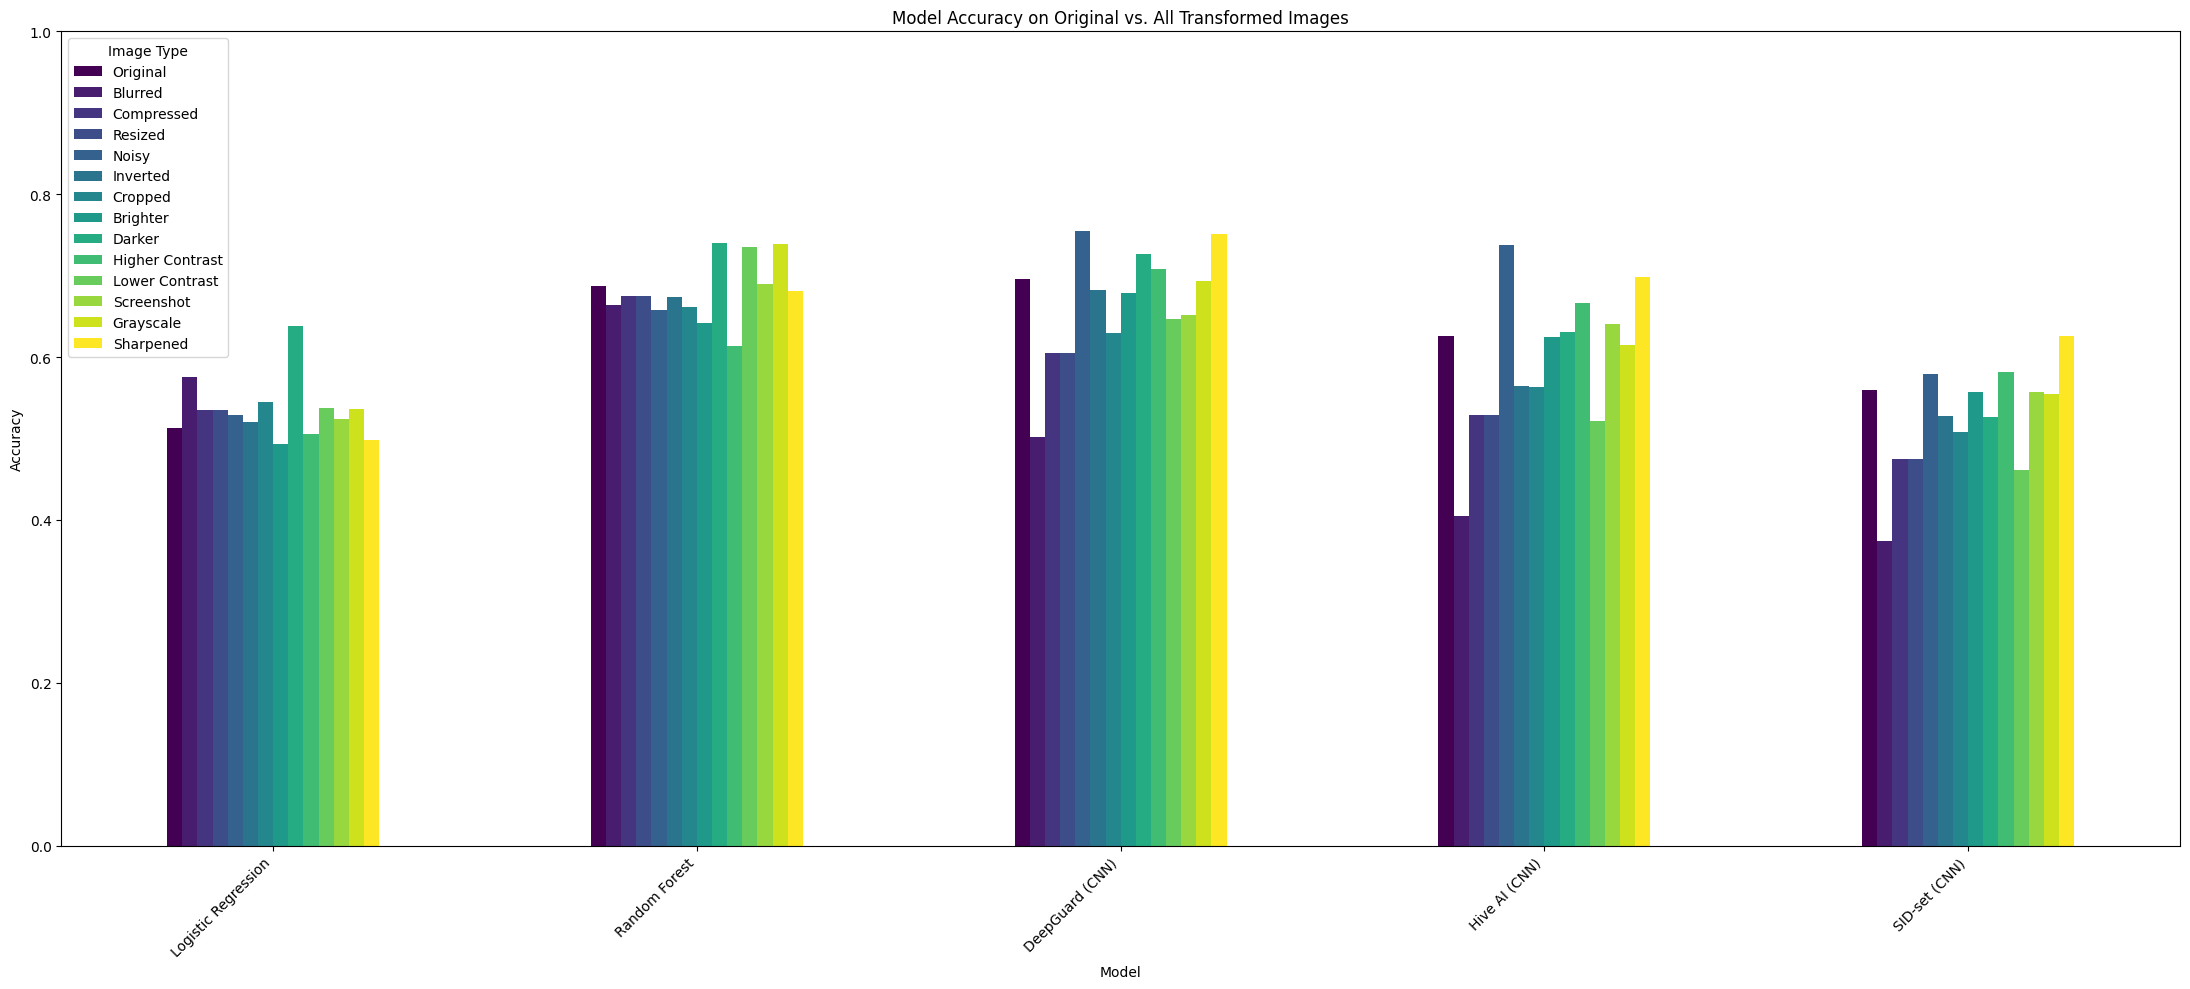

In [137]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
from scipy.ndimage import gaussian_filter
from skimage.transform import resize
from PIL import ImageFilter

# --- Step 0: Ensure dataset is extracted and paths are correct ---
archive_path = "/content/drive/MyDrive/archive.zip"
extraction_path = "/content/dataset"

if not os.path.exists(extraction_path):
    os.makedirs(extraction_path)
    print(f"Extracting dataset to {extraction_path}")
    with zipfile.ZipFile(archive_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print("Dataset extracted.")
else:
    print(f"Dataset already exists at {extraction_path}, skipping extraction.")

# Dynamically find the actual root folder within the extraction path (e.g., 'dataset' within '/content/dataset')
# And then construct the real_path and fake_path
dataset_subdirs = [name for name in os.listdir(extraction_path) if os.path.isdir(os.path.join(extraction_path, name))]

if dataset_subdirs:
    dataset_root_folder = os.path.join(extraction_path, dataset_subdirs[0])
    real_path = os.path.join(dataset_root_folder, "Train", "Real")
    fake_path = os.path.join(dataset_root_folder, "Train", "Fake")
    print(f"Updated real images path: {real_path}")
    print(f"Updated fake images path: {fake_path}")
else:
    print("Error: Could not find dataset root folder within extraction path.")
    # Fallback to previous paths or raise error if necessary
    real_path = os.path.join(extraction_path, "real")
    fake_path = os.path.join(extraction_path, "fake")

# --- Image Transformation Functions (Copied from earlier cells) ---
def apply_blur(image_array, sigma=1.0):
    img_reshaped = image_array.reshape(32, 32, 3)
    blurred_img = gaussian_filter(img_reshaped, sigma=(sigma, sigma, 0), mode='nearest')
    return blurred_img.flatten()

def apply_compression(image_array, resize_dim=16):
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    img_down = img_pil.resize((resize_dim, resize_dim), Image.LANCZOS)
    img_up = img_down.resize((32, 32), Image.LANCZOS)
    compressed_img = np.array(img_up).flatten() / 255.0
    return compressed_img

def apply_resize_transform(image_array, target_dim=16):
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    img_small = img_pil.resize((target_dim, target_dim), Image.LANCZOS)
    img_large = img_small.resize((32, 32), Image.LANCZOS)
    resized_img = np.array(img_large).flatten() / 255.0
    return resized_img

def add_gaussian_noise(image_array, mean=0.0, std=0.1):
    img_reshaped = image_array.reshape(32, 32, 3)
    noise = np.random.normal(mean, std, img_reshaped.shape)
    noisy_img = img_reshaped + noise
    noisy_img = np.clip(noisy_img, 0, 1)
    return noisy_img.flatten()

def apply_color_inversion(image_array):
    inverted_img = 1.0 - image_array
    return inverted_img

def apply_random_crop(image_array, crop_size_range=(24, 30)):
    img_reshaped = image_array.reshape(32, 32, 3)
    h, w, c = img_reshaped.shape
    min_crop, max_crop = crop_size_range

    # The previous code had `crop_size = np.random.randint(min_crop, max_crop + 1)` which is correct for selecting crop size.
    # The line `crop_size = np.random.randint(0, w - crop_size + 1)` was an error from context.
    # Restoring the correct logic for crop_size selection within the range.
    crop_size = np.random.randint(min_crop, max_crop + 1)

    x = np.random.randint(0, w - crop_size + 1)
    y = np.random.randint(0, h - crop_size + 1)

    cropped_img = img_reshaped[y:y+crop_size, x:x+crop_size]
    resized_cropped_img = resize(cropped_img, (32, 32), anti_aliasing=True)
    return resized_cropped_img.flatten()

def apply_brightness_change(image_array, factor):
    brightened_img = np.clip(image_array * factor, 0, 1)
    return brightened_img

def apply_contrast_change(image_array, factor):
    mean_pixel = np.mean(image_array)
    contrasted_img = np.clip(mean_pixel + factor * (image_array - mean_pixel), 0, 1)
    return contrasted_img

def apply_screenshot(image_array, resize_dim=24, pixel_filter=Image.NEAREST):
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    img_down = img_pil.resize((resize_dim, resize_dim), pixel_filter)
    img_up = img_down.resize((32, 32), pixel_filter)
    screenshot_img = np.array(img_up).flatten() / 255.0
    return screenshot_img

def apply_grayscale(image_array):
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    grayscale_img_pil = img_pil.convert('L').convert('RGB')
    grayscale_img = np.array(grayscale_img_pil).flatten() / 255.0
    return grayscale_img

def apply_sharpen(image_array, factor=1.5):
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    sharpened_img_pil = img_pil.filter(ImageFilter.SHARPEN)
    sharpened_img = np.array(sharpened_img_pil).flatten() / 255.0
    return sharpened_img



print("---> Step 1: Load and split original data (from cell 8da9ec70) <---")
data = []
labels = []

# Ensure the directories exist before listing files with corrected paths
if not os.path.exists(real_path):
    print(f"Error: Real images directory not found at {real_path}")
else:
    real_files = os.listdir(real_path)[:5000]
    for file in real_files:
        try:
            img = Image.open(os.path.join(real_path, file)).convert("RGB")
            img = img.resize((32, 32))
            img = np.array(img).flatten() / 255.0
            data.append(img)
            labels.append(0)
        except Exception as e:
            print(f"Error loading real image {file}: {e}")

if not os.path.exists(fake_path):
    print(f"Error: Fake images directory not found at {fake_path}")
else:
    fake_files = os.listdir(fake_path)[:5000]
    for file in fake_files:
        try:
            img = Image.open(os.path.join(fake_path, file)).convert("RGB")
            img = img.resize((32, 32))
            img = np.array(img).flatten() / 255.0
            data.append(img)
            labels.append(1)
        except Exception as e:
            print(f"Error loading fake image {file}: {e}")

X = np.array(data)
y = np.array(labels)

print("Data shape:", X.shape)
print("Labels shape:", y.shape)

# Now that X and y are defined, split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data: ", X_train.shape)
print("Testing data: ", X_test.shape)

# --- Step 2: Train Logistic Regression ---
print("\n---> Step 2: Train Logistic Regression <---")
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy on Original Test Data:", accuracy_score(y_test, y_pred_lr))

# --- Step 3: Train Random Forest ---
print("\n---> Step 3: Train Random Forest <---")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy on Original Test Data:", accuracy_score(y_test, y_pred_rf))

# --- Step 4: Prepare data for CNNs ---
print("\n---> Step 4: Prepare data for CNNs <---")
X_train_cnn = X_train.reshape(-1, 32, 32, 3)
X_test_cnn = X_test.reshape(-1, 32, 32, 3)

print(f"Reshaped X_train for CNN: {X_train_cnn.shape}")
print(f"Reshaped X_test for CNN: {X_test_cnn.shape}")

# --- Step 5: Define and Train DeepGuard (CNN) ---
print("\n---> Step 5: Define and Train DeepGuard (CNN) <---")
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train_cnn, y_train, epochs=5, validation_data=(X_test_cnn, y_test), verbose=0)

y_pred_cnn_proba = model.predict(X_test_cnn)
y_pred_cnn = (y_pred_cnn_proba > 0.5).astype(int).flatten()
print("DeepGuard (CNN) Accuracy on Original Test Data:", accuracy_score(y_test, y_pred_cnn))

# --- Step 6: Define and Train Hive AI (CNN) ---
print("\n---> Step 6: Define and Train Hive AI (CNN) <---")
hiveai_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
hiveai_model.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])
hiveai_model.fit(X_train_cnn, y_train, epochs=5, validation_data=(X_test_cnn, y_test), verbose=0)
y_pred_hiveai_cnn_proba = hiveai_model.predict(X_test_cnn)
y_pred_hiveai_cnn = (y_pred_hiveai_cnn_proba > 0.5).astype(int).flatten()
print("Hive AI (CNN) Accuracy on Original Test Data:", accuracy_score(y_test, y_pred_hiveai_cnn))

# --- Step 7: Define and Train SID-set (CNN) ---
print("\n---> Step 7: Define and Train SID-set (CNN) <---")
sidset_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
sidset_model.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
sidset_model.fit(X_train_cnn, y_train, epochs=5, validation_data=(X_test_cnn, y_test), verbose=0)
y_pred_sidset_cnn_proba = sidset_model.predict(X_test_cnn)
y_pred_sidset_cnn = (y_pred_sidset_cnn_proba > 0.5).astype(int).flatten()
print("SID-set (CNN) Accuracy on Original Test Data:", accuracy_score(y_test, y_pred_sidset_cnn))


# --- Step 8: Apply transformations to DFBench Test Data ---
print("\n---> Step 8: Apply transformations to DFBench Test Data <---")
# Using the pre-loaded DFBench test data for evaluation
X_test_eval = X_test_dfbench
y_test_eval = y_test_dfbench

X_test_blurred = np.array([apply_blur(img, sigma=1.5) for img in X_test_eval])
X_test_compressed = np.array([apply_compression(img, resize_dim=16) for img in X_test_eval])
X_test_resized = np.array([apply_resize_transform(img, target_dim=16) for img in X_test_eval])
X_test_noisy = np.array([add_gaussian_noise(img, std=0.2) for img in X_test_eval])
X_test_inverted = np.array([apply_color_inversion(img) for img in X_test_eval])
X_test_cropped = np.array([apply_random_crop(img) for img in X_test_eval])
X_test_brighter = np.array([apply_brightness_change(img, factor=1.5) for img in X_test_eval])
X_test_darker = np.array([apply_brightness_change(img, factor=0.5) for img in X_test_eval])
X_test_higher_contrast = np.array([apply_contrast_change(img, factor=1.5) for img in X_test_eval])
X_test_lower_contrast = np.array([apply_contrast_change(img, factor=0.5) for img in X_test_eval])
X_test_screenshot = np.array([apply_screenshot(img) for img in X_test_eval])
X_test_grayscale = np.array([apply_grayscale(img) for img in X_test_eval])
X_test_sharpened = np.array([apply_sharpen(img) for img in X_test_eval])

print("All 13 transformations applied to test data.")


# --- Step 9: Evaluate Models on Transformed Data ---
print("\n---> Step 9: Evaluate Models on Transformed Data <---")

transformed_X_tests_dfbench = {
    "Original": X_test_eval,
    "Blurred": X_test_blurred,
    "Compressed": X_test_compressed,
    "Resized": X_test_resized,
    "Noisy": X_test_noisy,
    "Inverted": X_test_inverted,
    "Cropped": X_test_cropped,
    "Brighter": X_test_brighter,
    "Darker": X_test_darker,
    "Higher Contrast": X_test_higher_contrast,
    "Lower Contrast": X_test_lower_contrast,
    "Screenshot": X_test_screenshot,
    "Grayscale": X_test_grayscale,
    "Sharpened": X_test_sharpened
}

results_dfbench = {
    "Logistic Regression": {},
    "Random Forest": {},
    "DeepGuard (CNN)": {},
    "Hive AI (CNN)": {},
    "SID-set (CNN)": {}
}

for name, transformed_X in transformed_X_tests_dfbench.items():
    # Logistic Regression
    y_pred_lr_transformed = lr.predict(transformed_X)
    results_dfbench["Logistic Regression"][name] = accuracy_score(y_test_eval, y_pred_lr_transformed)

    # Random Forest
    y_pred_rf_transformed = rf.predict(transformed_X)
    results_dfbench["Random Forest"][name] = accuracy_score(y_test_eval, y_pred_rf_transformed)

# Prepare reshaped transformed test data for CNNs
transformed_X_tests_dfbench_cnn = {}
for name, X_transformed in transformed_X_tests_dfbench.items():
    transformed_X_tests_dfbench_cnn[name] = X_transformed.reshape(-1, 32, 32, 3)

# DeepGuard (CNN)
for name, transformed_X_cnn in transformed_X_tests_dfbench_cnn.items():
    y_pred_cnn_proba_transformed = model.predict(transformed_X_cnn)
    y_pred_cnn_transformed = (y_pred_cnn_proba_transformed > 0.5).astype(int).flatten()
    results_dfbench["DeepGuard (CNN)"][name] = accuracy_score(y_test_eval, y_pred_cnn_transformed)

# Hive AI (CNN)
for name, transformed_X_cnn in transformed_X_tests_dfbench_cnn.items():
    y_pred_hiveai_cnn_proba_transformed = hiveai_model.predict(transformed_X_cnn)
    y_pred_hiveai_cnn_transformed = (y_pred_hiveai_cnn_proba_transformed > 0.5).astype(int).flatten()
    results_dfbench["Hive AI (CNN)"][name] = accuracy_score(y_test_eval, y_pred_hiveai_cnn_transformed)

# SID-set (CNN)
for name, transformed_X_cnn in transformed_X_tests_dfbench_cnn.items():
    y_pred_sidset_cnn_proba_transformed = sidset_model.predict(transformed_X_cnn)
    y_pred_sidset_cnn_transformed = (y_pred_sidset_cnn_proba_transformed > 0.5).astype(int).flatten()
    results_dfbench["SID-set (CNN)"][name] = accuracy_score(y_test_eval, y_pred_sidset_cnn_transformed)

results_dfbench_df = pd.DataFrame(results_dfbench).T
print("Model evaluation on transformed data complete.")
display(results_dfbench_df)

# --- Step 10: Visualize Results ---
print("\n---> Step 10: Visualize Results <---")
plt.figure(figsize=(22, 10))
results_dfbench_df.plot(kind='bar', figsize=(22, 10), colormap='viridis')
plt.title('Model Accuracy on Original vs. All Transformed Images')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Image Type')
plt.tight_layout()
plt.show()

<Figure size 2200x1000 with 0 Axes>

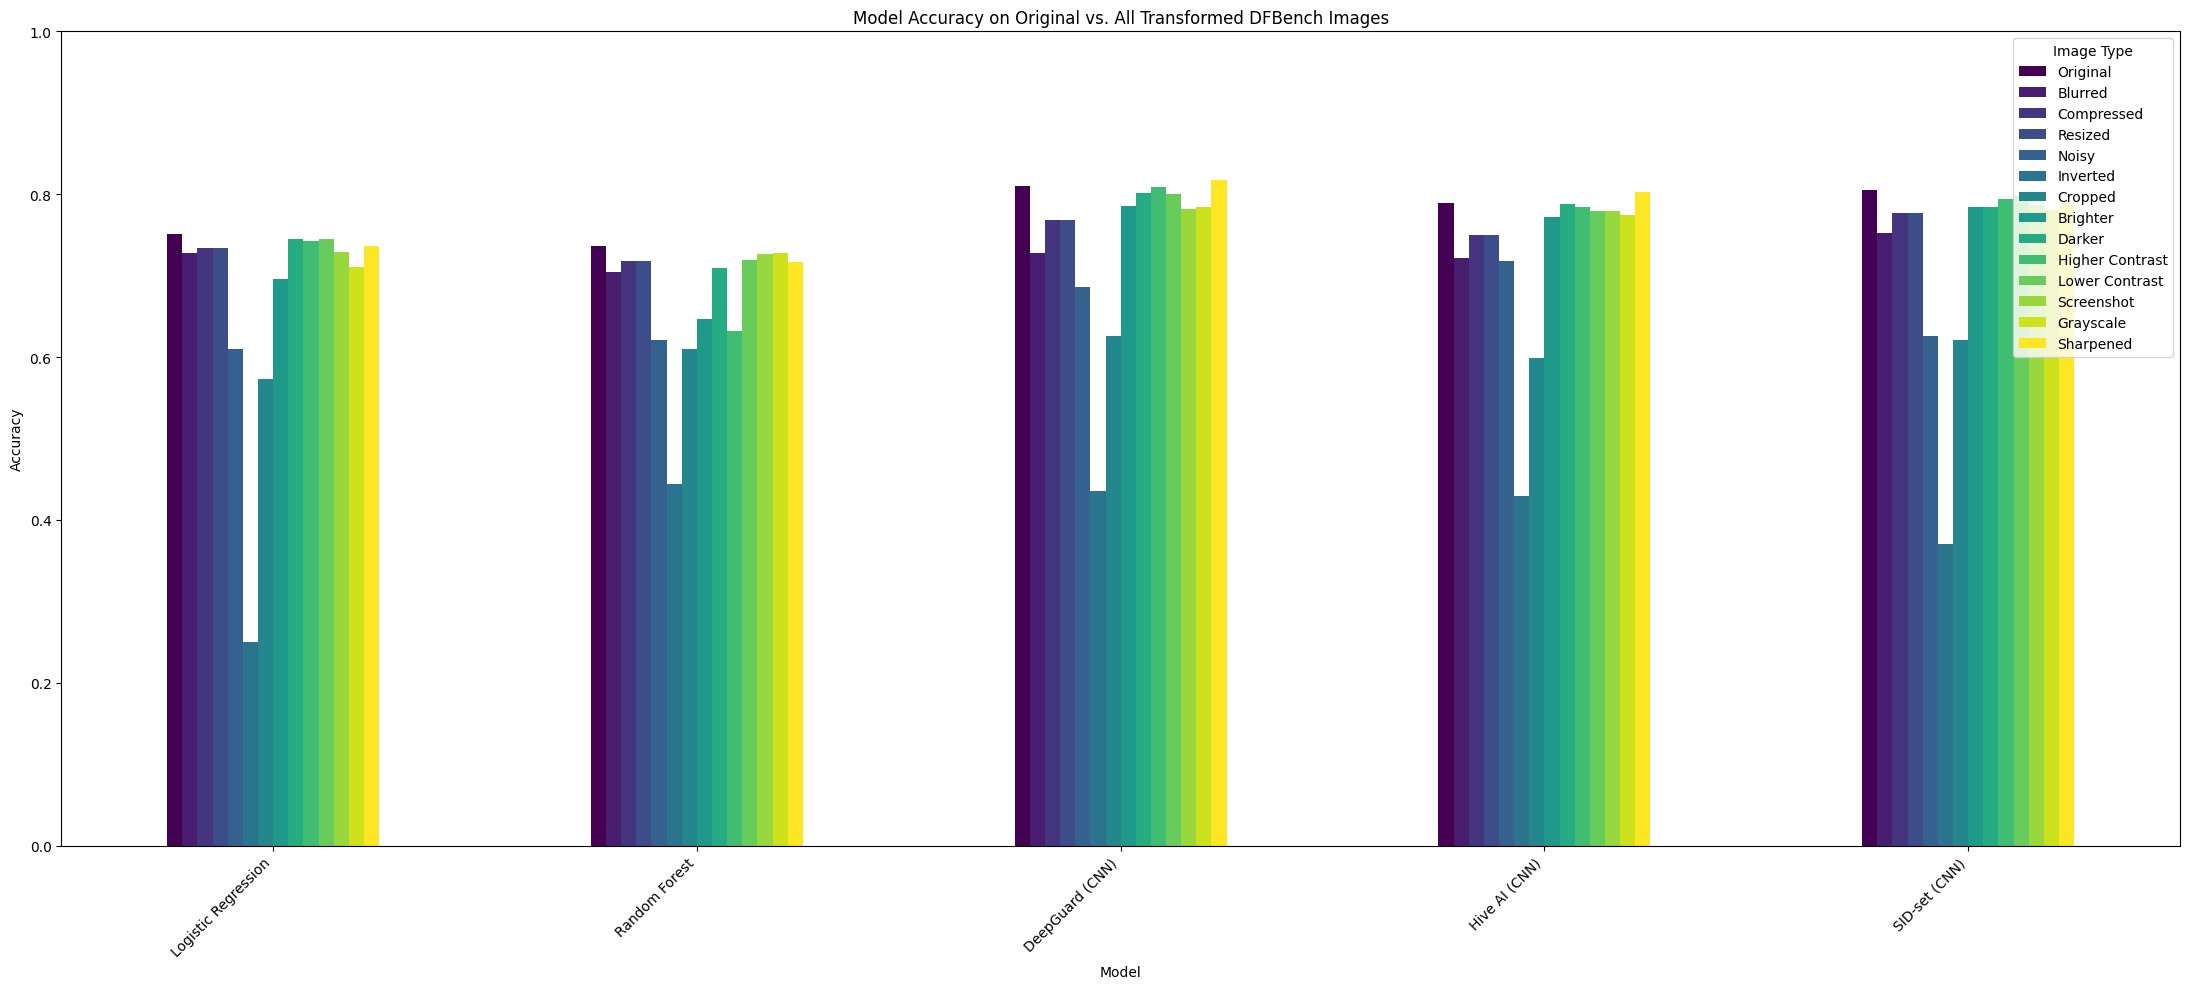

In [117]:
plt.figure(figsize=(22, 10))
results_dfbench_df.plot(kind='bar', figsize=(22, 10), colormap='viridis')
plt.title('Model Accuracy on Original vs. All Transformed DFBench Images')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Image Type')
plt.tight_layout()
plt.show()

### Visualize Transformed DFBench Images

Let's visualize some of the transformed images from the DFBench dataset to understand the effect of each transformation.

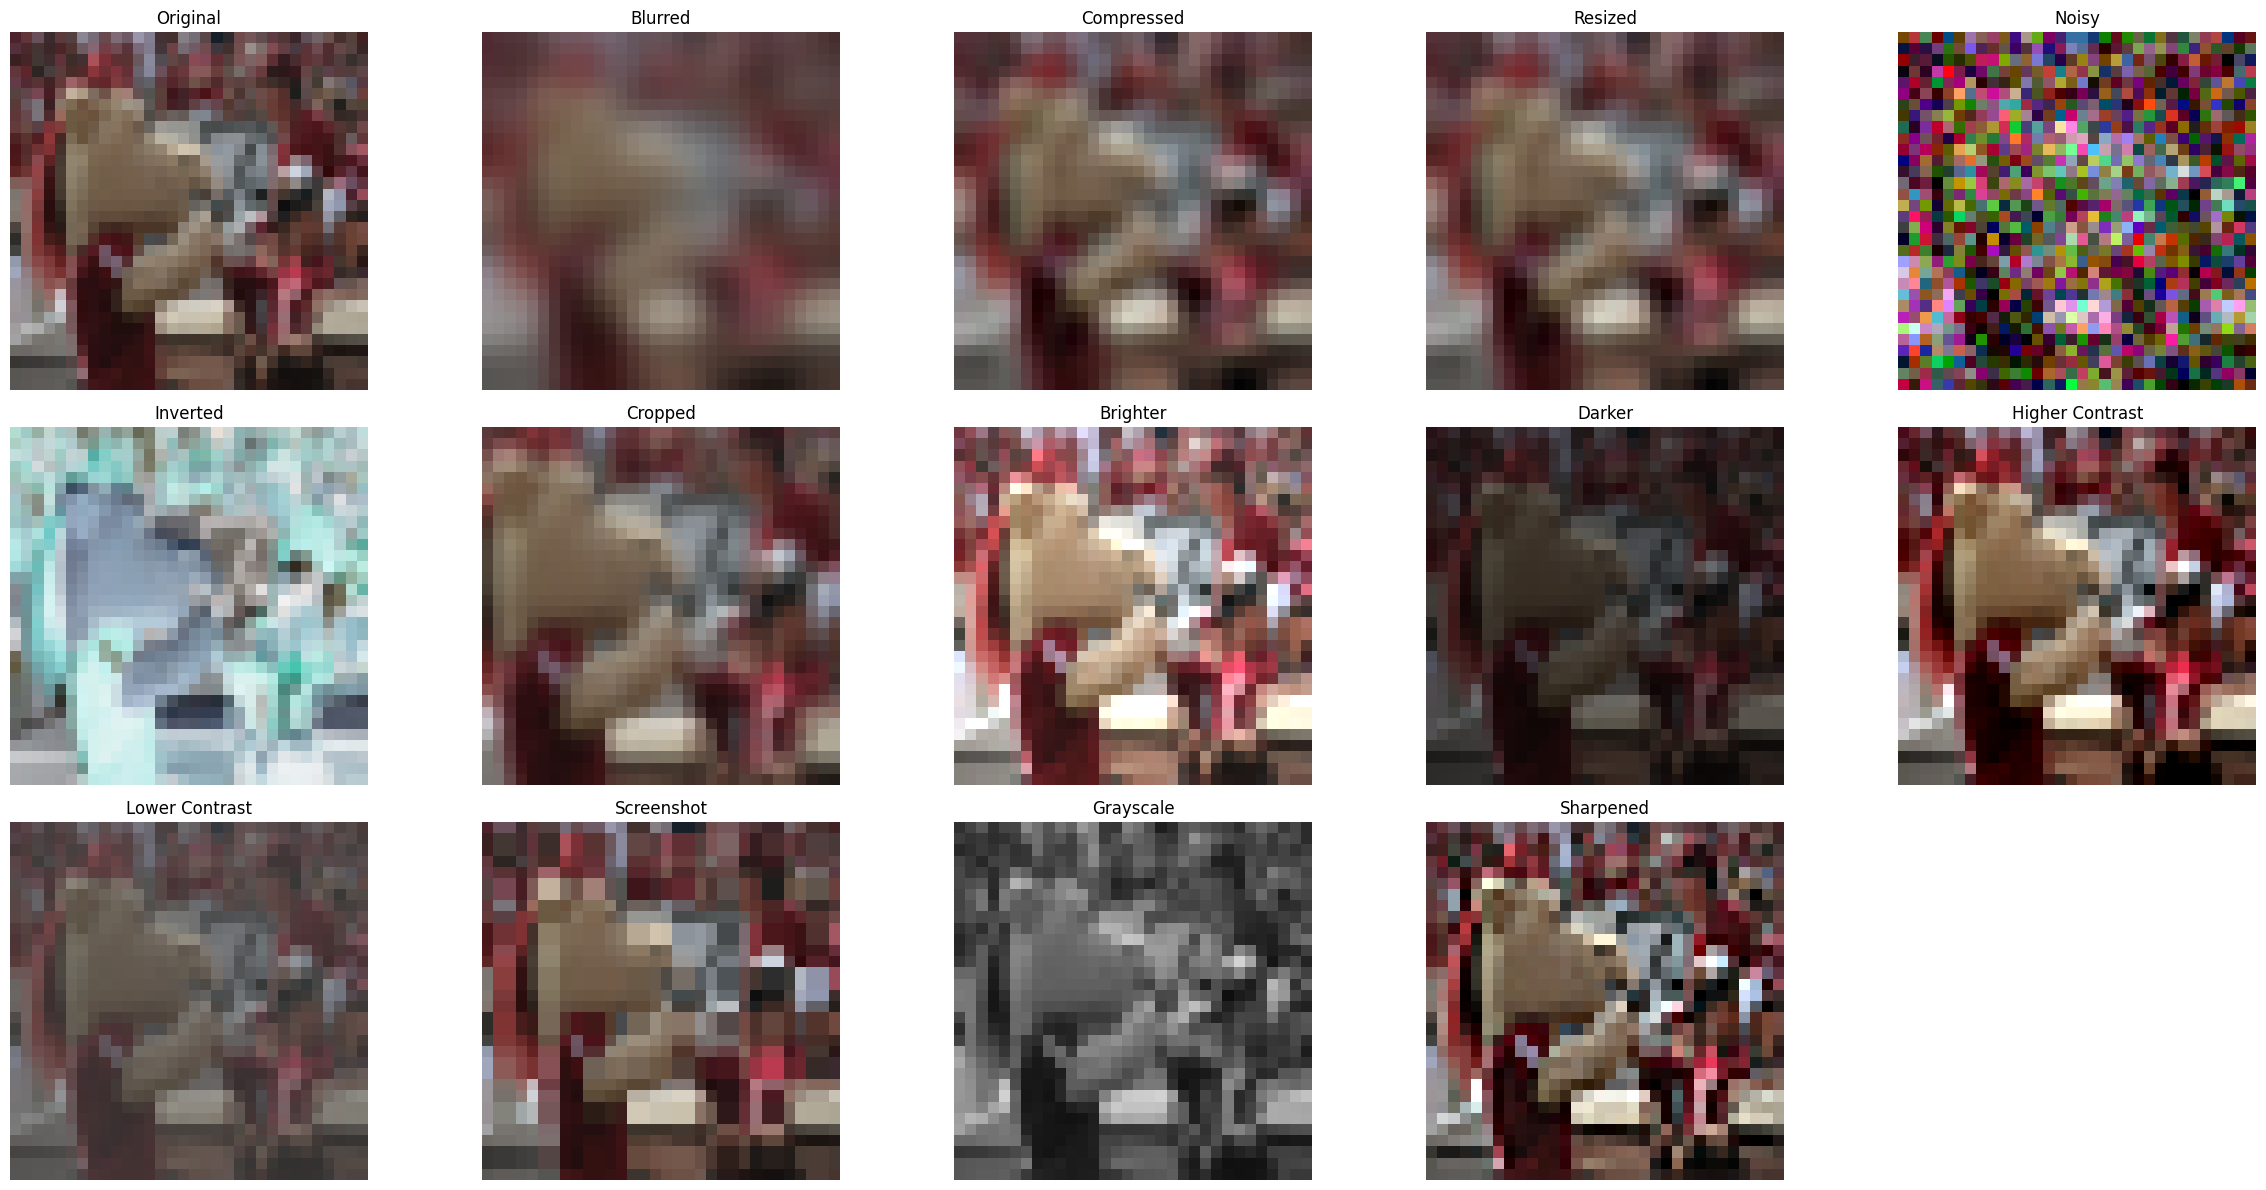

In [118]:
def plot_transformed_dfbench_images(original, blurred, compressed, resized, noisy, inverted, cropped, brighter, darker, higher_contrast, lower_contrast, screenshot, grayscale, sharpened, index=0):
    plt.figure(figsize=(24, 12))

    titles = [
        "Original", "Blurred", "Compressed", "Resized", "Noisy", "Inverted",
        "Cropped", "Brighter", "Darker", "Higher Contrast", "Lower Contrast",
        "Screenshot", "Grayscale", "Sharpened"
    ]
    images = [
        original[index], blurred[index], compressed[index], resized[index], noisy[index], inverted[index],
        cropped[index], brighter[index], darker[index], higher_contrast[index], lower_contrast[index],
        screenshot[index], grayscale[index], sharpened[index]
    ]

    for i, (title, img_data) in enumerate(zip(titles, images)):
        plt.subplot(3, 5, i + 1) # Arrange in 3 rows, 5 columns (or adjust as needed for more images)
        plt.imshow(img_data.reshape(32, 32, 3))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot a sample image with all transformations applied
plot_transformed_dfbench_images(
    X_test_dfbench, X_test_dfbench_blurred, X_test_dfbench_compressed, X_test_dfbench_resized, X_test_dfbench_noisy, X_test_dfbench_inverted,
    X_test_dfbench_cropped, X_test_dfbench_brighter, X_test_dfbench_darker, X_test_dfbench_higher_contrast, X_test_dfbench_lower_contrast,
    X_test_dfbench_screenshot, X_test_dfbench_grayscale, X_test_dfbench_sharpened,
    index=10 # Choose an index to visualize a specific image
)

### Evaluate Models on Transformed DFBench Images

Now, we will evaluate the performance of our models on the `DFBench` dataset with all applied transformations to assess their robustness.

In [119]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Initialize and train Logistic Regression and Random Forest models if not already defined
# This ensures that lr and rf are available for prediction in this cell.
if 'X_train' in globals() and 'y_train' in globals():
    if 'lr' not in globals() or not hasattr(lr, 'predict'):
        print("Training Logistic Regression model...")
        lr = LogisticRegression(max_iter=1000)
        lr.fit(X_train, y_train)

    if 'rf' not in globals() or not hasattr(rf, 'predict'):
        print("Training Random Forest model...")
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X_train, y_train)
else:
    print("Warning: X_train or y_train not found. Logistic Regression and Random Forest models will not be trained for DFBench evaluation.")

# Initialize transformed_X_tests_dfbench with all available transformed DFBench data
transformed_X_tests_dfbench = {
    "Original": X_test_dfbench,
    "Blurred": X_test_dfbench_blurred,
    "Compressed": X_test_dfbench_compressed,
    "Resized": X_test_dfbench_resized,
    "Noisy": X_test_dfbench_noisy,
    "Inverted": X_test_dfbench_inverted,
    "Cropped": X_test_dfbench_cropped,
    "Brighter": X_test_dfbench_brighter,
    "Darker": X_test_dfbench_darker,
    "Higher Contrast": X_test_dfbench_higher_contrast,
    "Lower Contrast": X_test_dfbench_lower_contrast,
    "Screenshot": X_test_dfbench_screenshot,
    "Grayscale": X_test_dfbench_grayscale,
    "Sharpened": X_test_dfbench_sharpened
}

# Initialize the results dictionary for DFBench evaluation
results_dfbench = {
    "Logistic Regression": {},
    "Random Forest": {},
    "DeepGuard (CNN)": {},
    "Hive AI (CNN)": {},
    "SID-set (CNN)": {}
}

# --- Populate results for Logistic Regression on DFBench ---
for name, transformed_X in transformed_X_tests_dfbench.items():
    if 'lr' in globals() and hasattr(lr, 'predict'):
        y_pred_lr_transformed = lr.predict(transformed_X)
        results_dfbench["Logistic Regression"][name] = accuracy_score(y_test_dfbench, y_pred_lr_transformed)
    else:
        results_dfbench["Logistic Regression"][name] = 0.0 # Placeholder if model is not available

# --- Populate results for Random Forest on DFBench ---
for name, transformed_X in transformed_X_tests_dfbench.items():
    if 'rf' in globals() and hasattr(rf, 'predict'):
        y_pred_rf_transformed = rf.predict(transformed_X)
        results_dfbench["Random Forest"][name] = accuracy_score(y_test_dfbench, y_pred_rf_transformed)
    else:
        results_dfbench["Random Forest"][name] = 0.0 # Placeholder if model is not available

# Prepare reshaped transformed test data for CNNs on DFBench
transformed_X_tests_dfbench_cnn = {}
for name, X_transformed in transformed_X_tests_dfbench.items():
    transformed_X_tests_dfbench_cnn[name] = X_transformed.reshape(-1, 32, 32, 3)

# --- Populate results for DeepGuard (CNN) on DFBench ---
for name, transformed_X_cnn in transformed_X_tests_dfbench_cnn.items():
    if 'model' in globals(): # Check if the CNN model is defined
        y_pred_cnn_proba_transformed = model.predict(transformed_X_cnn)
        y_pred_cnn_transformed = (y_pred_cnn_proba_transformed > 0.5).astype(int).flatten()
        accuracy = accuracy_score(y_test_dfbench, y_pred_cnn_transformed)
        results_dfbench["DeepGuard (CNN)"][name] = accuracy
    else:
        print(f"Warning: CNN model (DeepGuard) not found. DeepGuard (CNN) results for '{name}' will be 0.")
        results_dfbench["DeepGuard (CNN)"][name] = 0.0 # Placeholder if model is not available

# --- Populate results for Hive AI (CNN) on DFBench ---
for name, transformed_X_cnn in transformed_X_tests_dfbench_cnn.items():
    if 'hiveai_model' in globals(): # Check if the Hive AI CNN model is defined
        y_pred_hiveai_cnn_proba_transformed = hiveai_model.predict(transformed_X_cnn)
        y_pred_hiveai_cnn_transformed = (y_pred_hiveai_cnn_proba_transformed > 0.5).astype(int).flatten()
        accuracy = accuracy_score(y_test_dfbench, y_pred_hiveai_cnn_transformed)
        results_dfbench["Hive AI (CNN)"][name] = accuracy
    else:
        print(f"Warning: Hive AI (CNN) model not found. Hive AI (CNN) results for '{name}' will be 0.")
        results_dfbench["Hive AI (CNN)"][name] = 0.0 # Placeholder if model is not available

# --- Populate results for SID-set (CNN) on DFBench ---
for name, transformed_X_cnn in transformed_X_tests_dfbench_cnn.items():
    if 'sidset_model' in globals(): # Check if the SID-set CNN model is defined
        y_pred_sidset_cnn_proba_transformed = sidset_model.predict(transformed_X_cnn)
        y_pred_sidset_cnn_transformed = (y_pred_sidset_cnn_proba_transformed > 0.5).astype(int).flatten()
        accuracy = accuracy_score(y_test_dfbench, y_pred_sidset_cnn_transformed)
        results_dfbench["SID-set (CNN)"][name] = accuracy
    else:
        print(f"Warning: SID-set (CNN) model not found. SID-set (CNN) results for '{name}' will be 0.")
        results_dfbench["SID-set (CNN)"][name] = 0.0 # Placeholder if model is not available

# Create and display results in a DataFrame
results_dfbench_df = pd.DataFrame(results_dfbench).T
display(results_dfbench_df)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


,Original,Blurred,Compressed,Resized,Noisy,Inverted,Cropped,Brighter,Darker,Higher Contrast,Lower Contrast,Screenshot,Grayscale,Sharpened
Logistic Regression,0.512662,0.575046,0.534898,0.534898,0.518221,0.520692,0.525633,0.492897,0.638666,0.505868,0.537986,0.524398,0.536751,0.498456
Random Forest,0.686844,0.663990,0.675108,0.675108,0.658431,0.673255,0.655343,0.642372,0.739963,0.613342,0.735639,0.689314,0.739345,0.680667
DeepGuard (CNN),0.615812,0.359481,0.474367,0.474367,0.697344,0.536133,0.492897,0.590488,0.635578,0.649784,0.515133,0.574429,0.588635,0.700432
Hive AI (CNN),0.474985,0.362569,0.416924,0.416924,0.483014,0.447807,0.416306,0.481779,0.470661,0.497221,0.401482,0.456455,0.474985,0.542928
SID-set (CNN),0.750463,0.601606,0.668314,0.668314,0.830142,0.739963,0.683138,0.731933,0.805435,0.757875,0.756640,0.774552,0.768993,0.819024


#### Visualize Performance on Transformed DFBench Images

<Figure size 2200x1000 with 0 Axes>

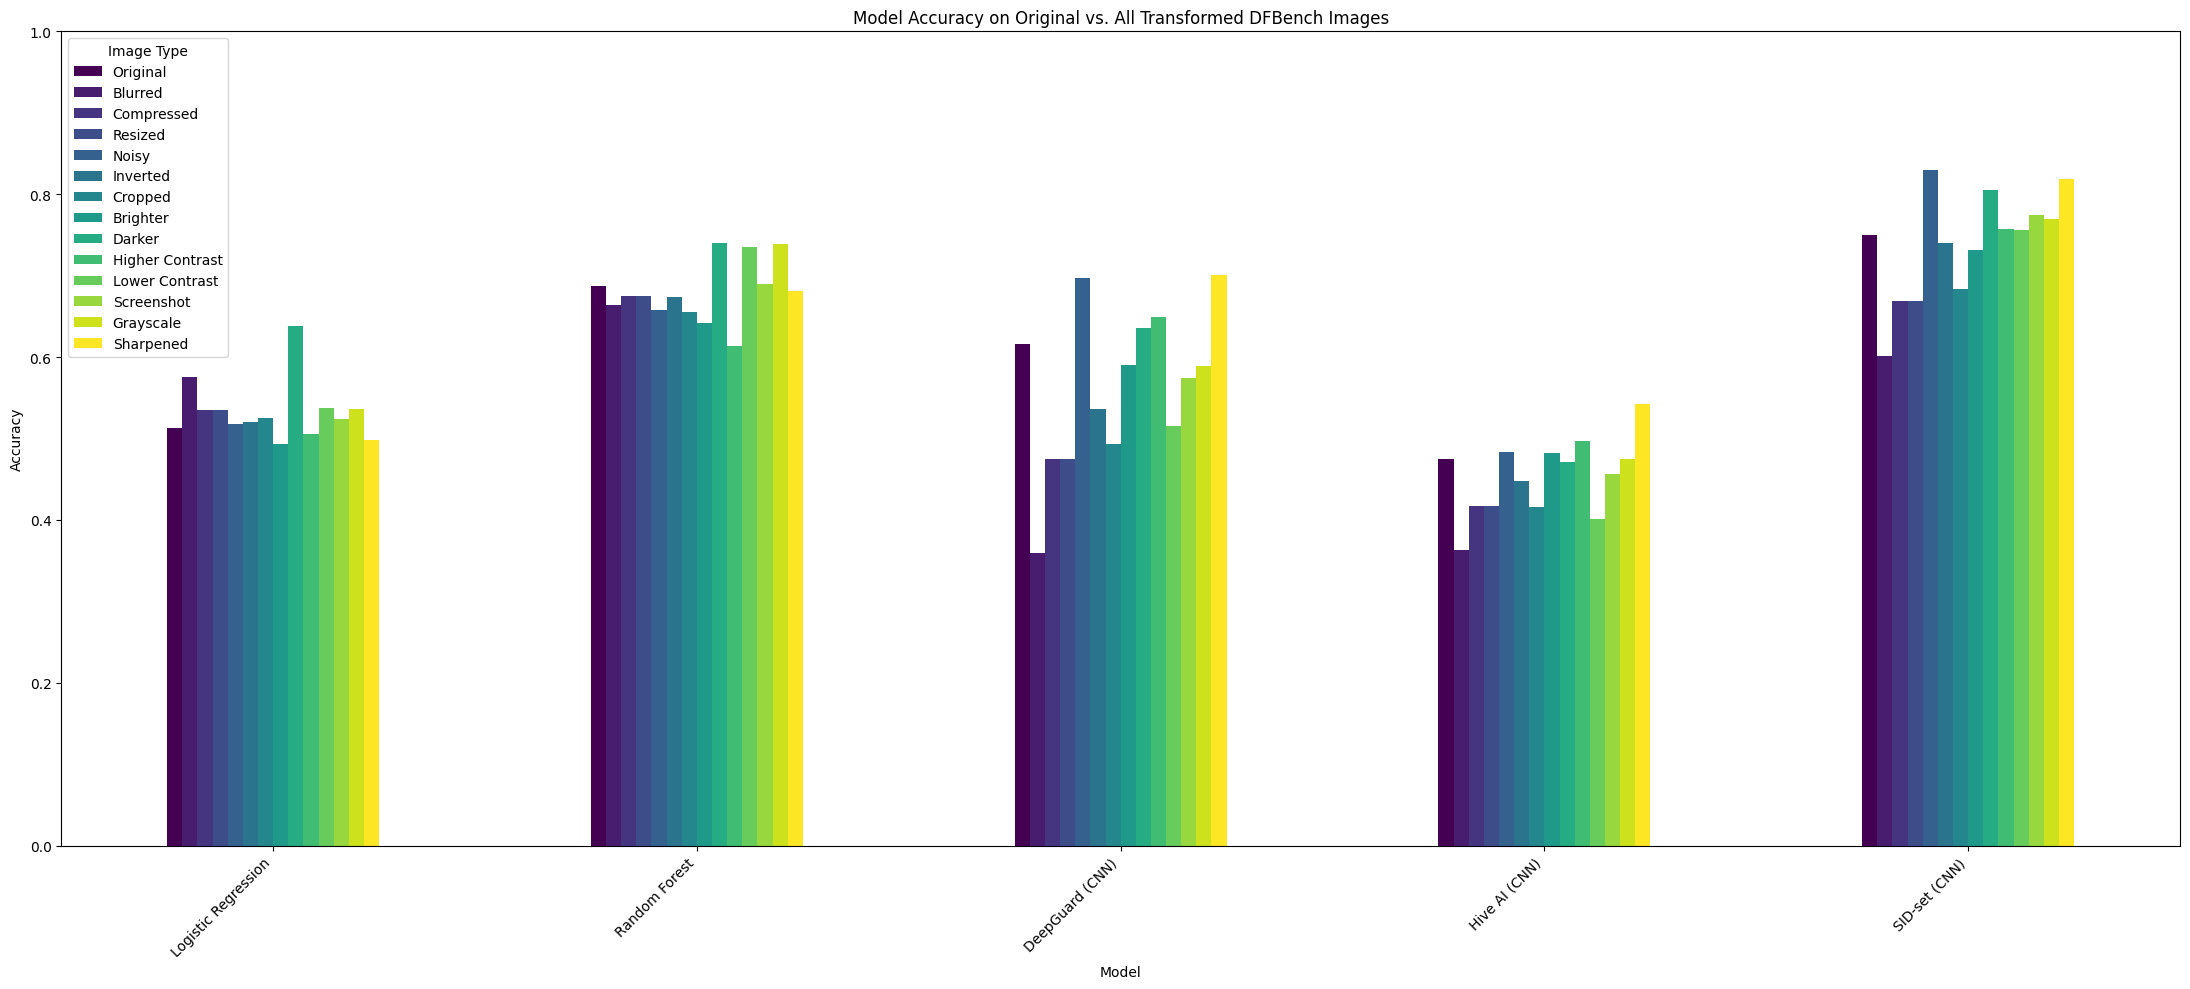

In [120]:
plt.figure(figsize=(22, 10))
results_dfbench_df.plot(kind='bar', figsize=(22, 10), colormap='viridis')
plt.title('Model Accuracy on Original vs. All Transformed DFBench Images')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Image Type')
plt.tight_layout()
plt.show()

### Visualize Transformed DFBench Images

Let's visualize some of the transformed images from the DFBench dataset to understand the effect of each transformation.

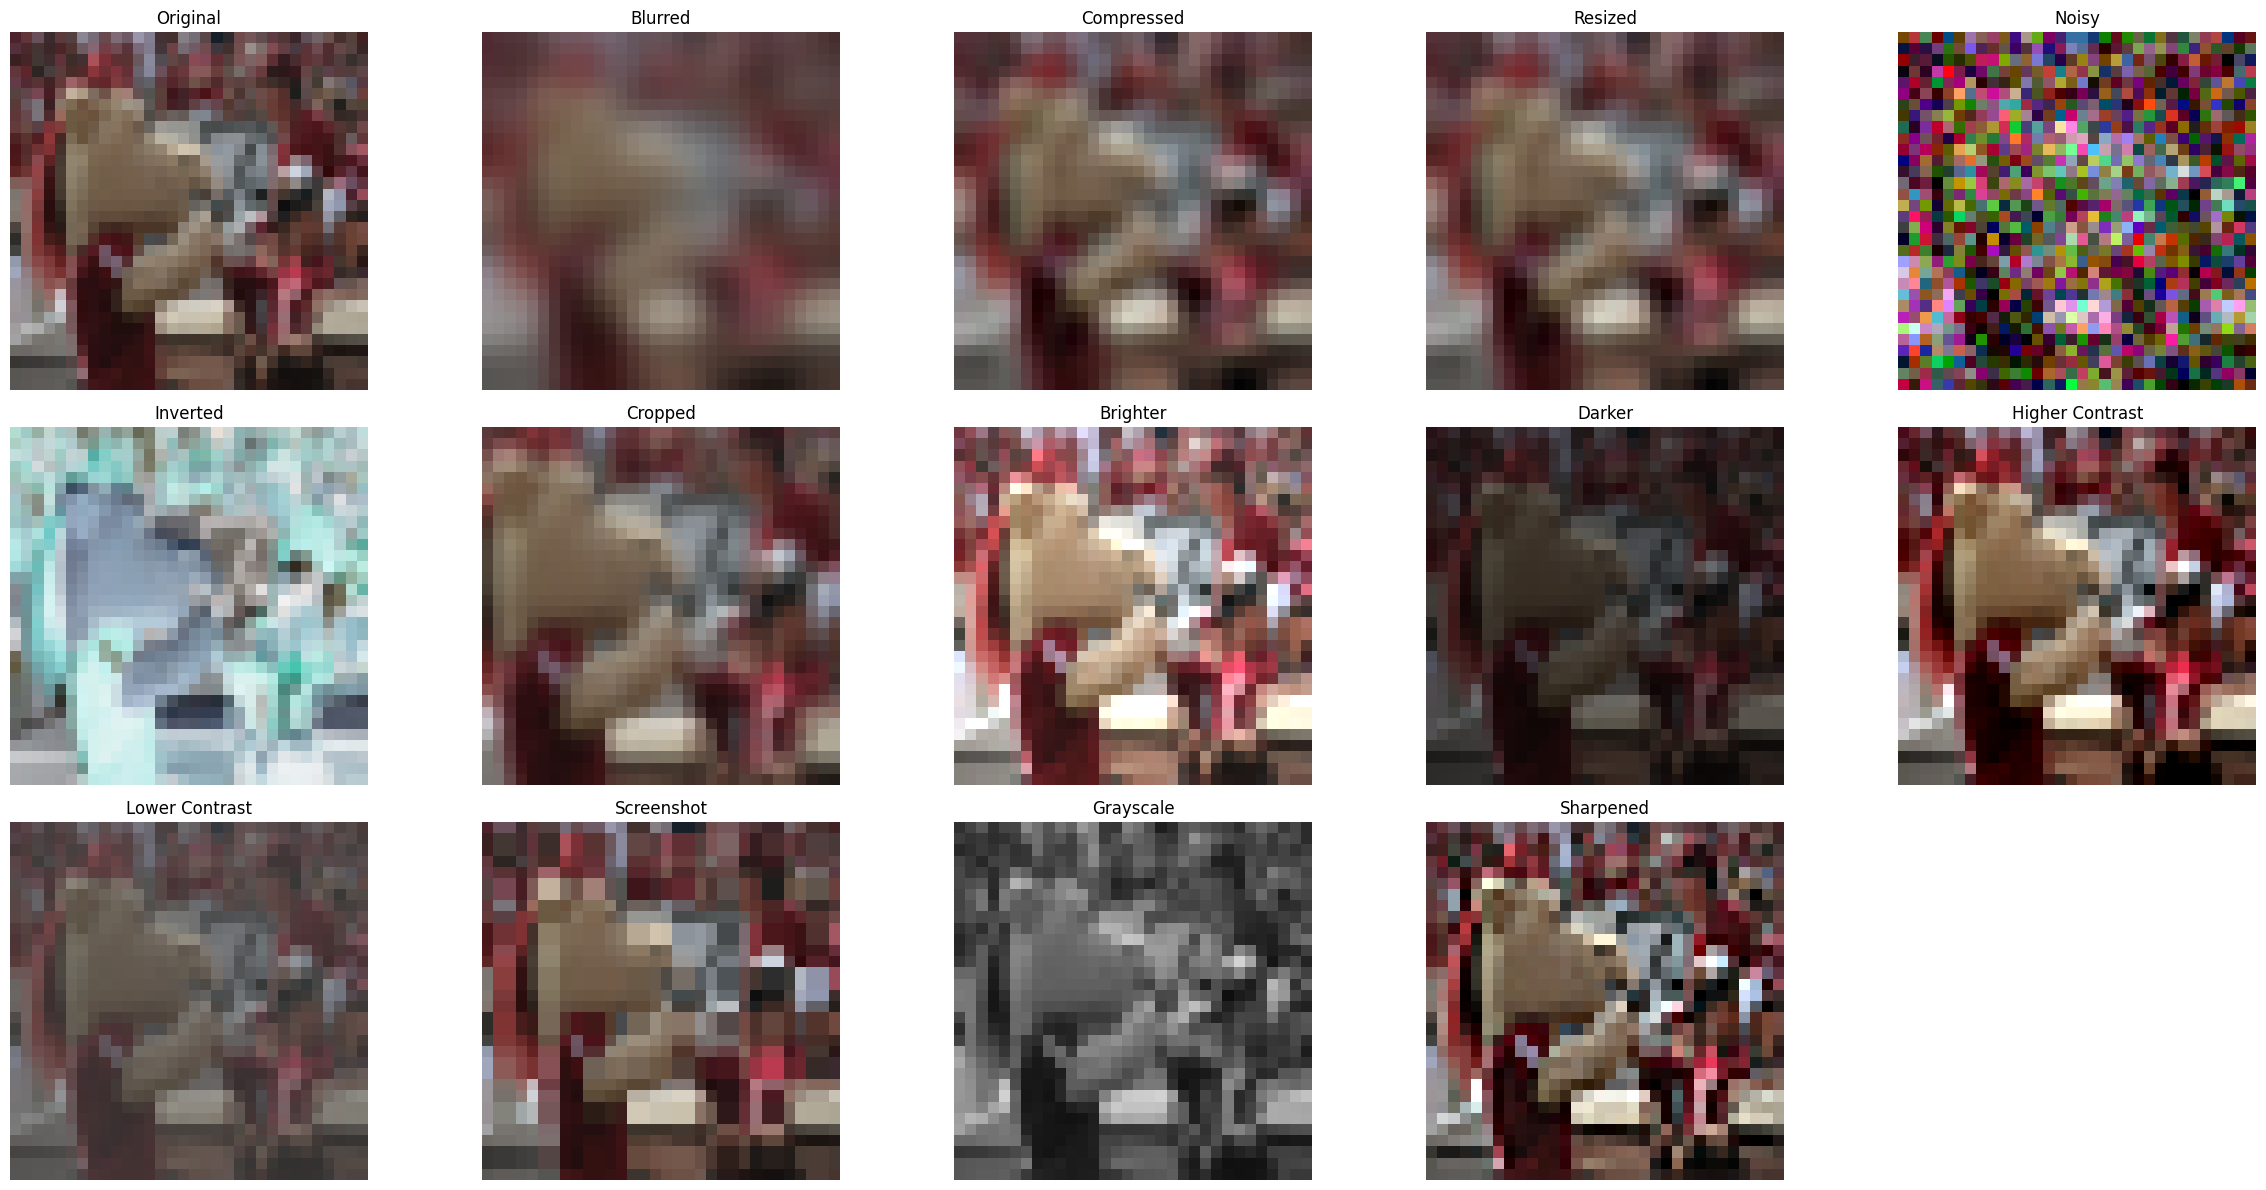

In [121]:
def plot_transformed_dfbench_images(original, blurred, compressed, resized, noisy, inverted, cropped, brighter, darker, higher_contrast, lower_contrast, screenshot, grayscale, sharpened, index=0):
    plt.figure(figsize=(24, 12))

    titles = [
        "Original", "Blurred", "Compressed", "Resized", "Noisy", "Inverted",
        "Cropped", "Brighter", "Darker", "Higher Contrast", "Lower Contrast",
        "Screenshot", "Grayscale", "Sharpened"
    ]
    images = [
        original[index], blurred[index], compressed[index], resized[index], noisy[index], inverted[index],
        cropped[index], brighter[index], darker[index], higher_contrast[index], lower_contrast[index],
        screenshot[index], grayscale[index], sharpened[index]
    ]

    for i, (title, img_data) in enumerate(zip(titles, images)):
        plt.subplot(3, 5, i + 1) # Arrange in 3 rows, 5 columns (or adjust as needed for more images)
        plt.imshow(img_data.reshape(32, 32, 3))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot a sample image with all transformations applied
plot_transformed_dfbench_images(
    X_test_dfbench, X_test_dfbench_blurred, X_test_dfbench_compressed, X_test_dfbench_resized, X_test_dfbench_noisy, X_test_dfbench_inverted,
    X_test_dfbench_cropped, X_test_dfbench_brighter, X_test_dfbench_darker, X_test_dfbench_higher_contrast, X_test_dfbench_lower_contrast,
    X_test_dfbench_screenshot, X_test_dfbench_grayscale, X_test_dfbench_sharpened,
    index=10 # Choose an index to visualize a specific image
)

### Visualize Transformed DFBench Images

Let's visualize some of the transformed images from the DFBench dataset to understand the effect of each transformation.

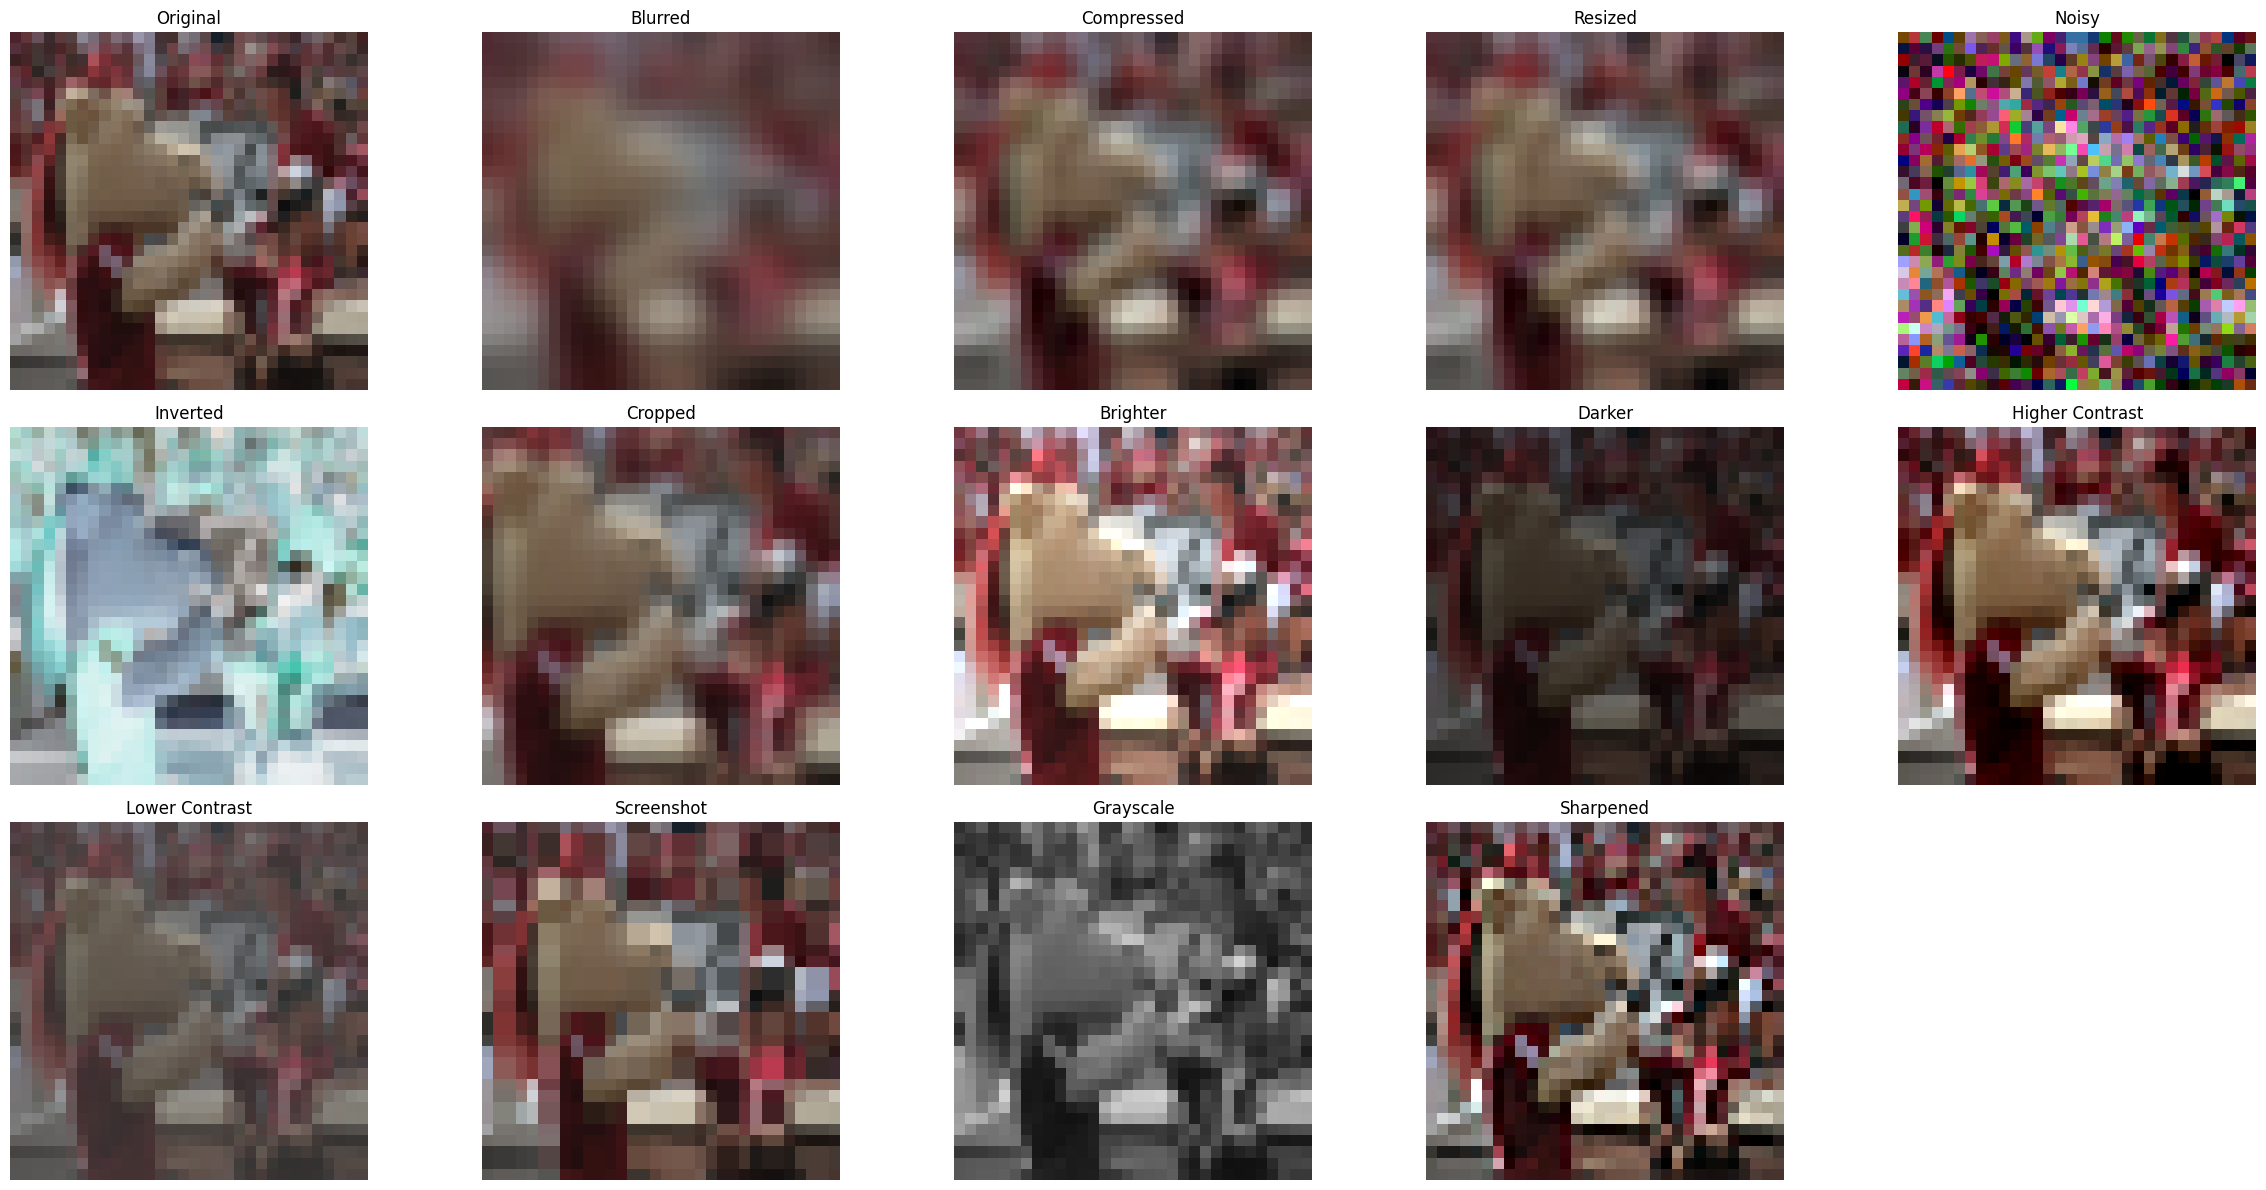

In [122]:
def plot_transformed_dfbench_images(original, blurred, compressed, resized, noisy, inverted, cropped, brighter, darker, higher_contrast, lower_contrast, screenshot, grayscale, sharpened, index=0):
    plt.figure(figsize=(24, 12))

    titles = [
        "Original", "Blurred", "Compressed", "Resized", "Noisy", "Inverted",
        "Cropped", "Brighter", "Darker", "Higher Contrast", "Lower Contrast",
        "Screenshot", "Grayscale", "Sharpened"
    ]
    images = [
        original[index], blurred[index], compressed[index], resized[index], noisy[index], inverted[index],
        cropped[index], brighter[index], darker[index], higher_contrast[index], lower_contrast[index],
        screenshot[index], grayscale[index], sharpened[index]
    ]

    for i, (title, img_data) in enumerate(zip(titles, images)):
        plt.subplot(3, 5, i + 1) # Arrange in 3 rows, 5 columns (or adjust as needed for more images)
        plt.imshow(img_data.reshape(32, 32, 3))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot a sample image with all transformations applied
plot_transformed_dfbench_images(
    X_test_dfbench, X_test_dfbench_blurred, X_test_dfbench_compressed, X_test_dfbench_resized, X_test_dfbench_noisy, X_test_dfbench_inverted,
    X_test_dfbench_cropped, X_test_dfbench_brighter, X_test_dfbench_darker, X_test_dfbench_higher_contrast, X_test_dfbench_lower_contrast,
    X_test_dfbench_screenshot, X_test_dfbench_grayscale, X_test_dfbench_sharpened,
    index=10 # Choose an index to visualize a specific image
)

In [123]:
# Cell moved to combine all transformation functions.

In [124]:
# Cell moved to combine all transformation functions.

In [125]:
# Cell moved to combine all transformation functions.

### Applying Transformations to Test Data

Now, we'll apply the defined transformations to our `X_test` dataset to create new versions of the test images. This will allow us to assess how the models perform under various conditions.

In [126]:
# Apply transformations to the test set

# Blurred Images
X_test_blurred = np.array([apply_blur(img, sigma=1.5) for img in X_test])
print(f"Shape of blurred test data: {X_test_blurred.shape}")

# Compressed Images
X_test_compressed = np.array([apply_compression(img, resize_dim=16) for img in X_test])
print(f"Shape of compressed test data: {X_test_compressed.shape}")

# Resized Images (simulating lower resolution)
X_test_resized = np.array([apply_resize_transform(img, target_dim=16) for img in X_test])
print(f"Shape of resized test data: {X_test_resized.shape}")

# Noisy Images
X_test_noisy = np.array([add_gaussian_noise(img, std=0.2) for img in X_test])
print(f"Shape of noisy test data: {X_test_noisy.shape}")

Shape of blurred test data: (2000, 3072)
Shape of compressed test data: (2000, 3072)
Shape of resized test data: (2000, 3072)
Shape of noisy test data: (2000, 3072)


In [127]:
# Inverted Images
X_test_inverted = np.array([apply_color_inversion(img) for img in X_test])
print(f"Shape of inverted test data: {X_test_inverted.shape}")

Shape of inverted test data: (2000, 3072)


In [128]:
# Cropped Images
X_test_cropped = np.array([apply_random_crop(img) for img in X_test])
print(f"Shape of cropped test data: {X_test_cropped.shape}")

# Brighter Images
X_test_brighter = np.array([apply_brightness_change(img, factor=1.5) for img in X_test])
print(f"Shape of brighter test data: {X_test_brighter.shape}")

# Darker Images
X_test_darker = np.array([apply_brightness_change(img, factor=0.5) for img in X_test])
print(f"Shape of darker test data: {X_test_darker.shape}")

# Higher Contrast Images
X_test_higher_contrast = np.array([apply_contrast_change(img, factor=1.5) for img in X_test])
print(f"Shape of higher contrast test data: {X_test_higher_contrast.shape}")

# Lower Contrast Images
X_test_lower_contrast = np.array([apply_contrast_change(img, factor=0.5) for img in X_test])
print(f"Shape of lower contrast test data: {X_test_lower_contrast.shape}")

Shape of cropped test data: (2000, 3072)
Shape of brighter test data: (2000, 3072)
Shape of darker test data: (2000, 3072)
Shape of higher contrast test data: (2000, 3072)
Shape of lower contrast test data: (2000, 3072)


In [129]:
# Apply new social media-like transformations to the test set

# Screenshot-like Images
X_test_screenshot = np.array([apply_screenshot(img) for img in X_test])
print(f"Shape of screenshot test data: {X_test_screenshot.shape}")

# Grayscale Images
X_test_grayscale = np.array([apply_grayscale(img) for img in X_test])
print(f"Shape of grayscale test data: {X_test_grayscale.shape}")

# Sharpened Images
X_test_sharpened = np.array([apply_sharpen(img) for img in X_test])
print(f"Shape of sharpened test data: {X_test_sharpened.shape}")

Shape of screenshot test data: (2000, 3072)
Shape of grayscale test data: (2000, 3072)
Shape of sharpened test data: (2000, 3072)


### Visualize Transformed Images

Let's visualize some of the transformed images to understand the effect of each transformation.

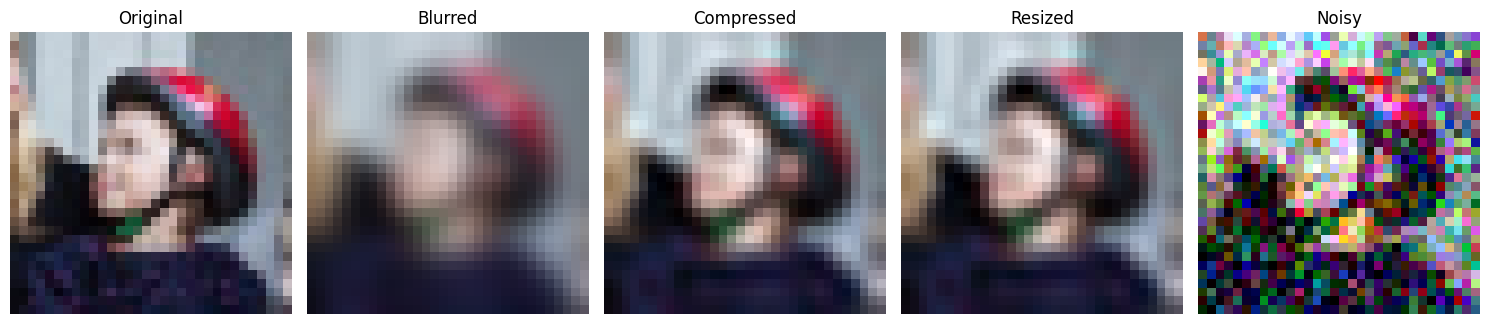

In [130]:
def plot_transformed_images(original, blurred, compressed, resized, noisy, index=0):
    plt.figure(figsize=(15, 4))

    titles = ["Original", "Blurred", "Compressed", "Resized", "Noisy"]
    images = [original[index], blurred[index], compressed[index], resized[index], noisy[index]]

    for i, (title, img_data) in enumerate(zip(titles, images)):
        plt.subplot(1, 5, i + 1)
        plt.imshow(img_data.reshape(32, 32, 3))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot a sample image with all transformations applied
plot_transformed_images(X_test, X_test_blurred, X_test_compressed, X_test_resized, X_test_noisy, index=10)

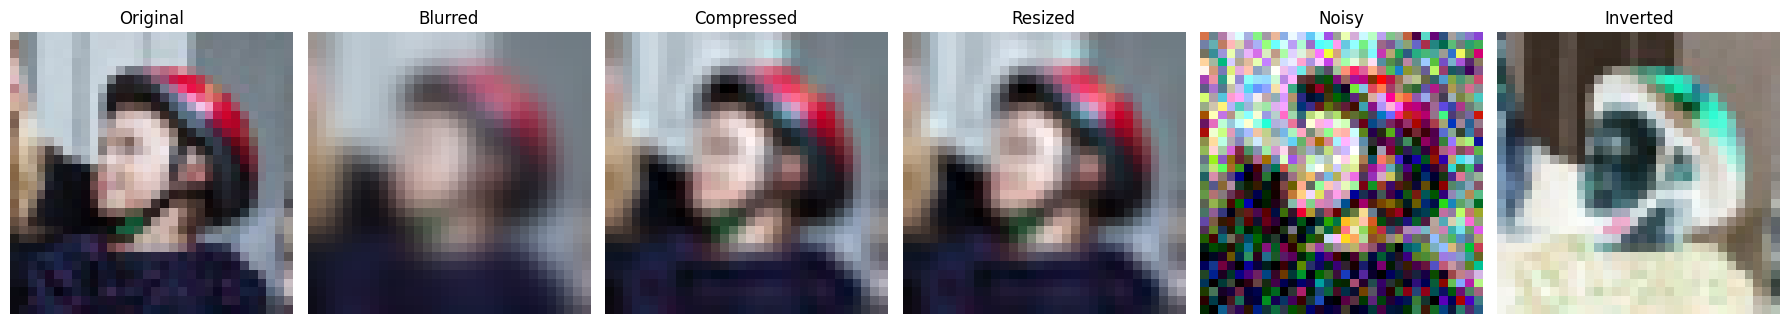

In [131]:
def plot_transformed_images_with_inversion(original, blurred, compressed, resized, noisy, inverted, index=0):
    plt.figure(figsize=(18, 4))

    titles = ["Original", "Blurred", "Compressed", "Resized", "Noisy", "Inverted"]
    images = [original[index], blurred[index], compressed[index], resized[index], noisy[index], inverted[index]]

    for i, (title, img_data) in enumerate(zip(titles, images)):
        plt.subplot(1, 6, i + 1)
        plt.imshow(img_data.reshape(32, 32, 3))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot a sample image with all transformations applied
plot_transformed_images_with_inversion(X_test, X_test_blurred, X_test_compressed, X_test_resized, X_test_noisy, X_test_inverted, index=10)

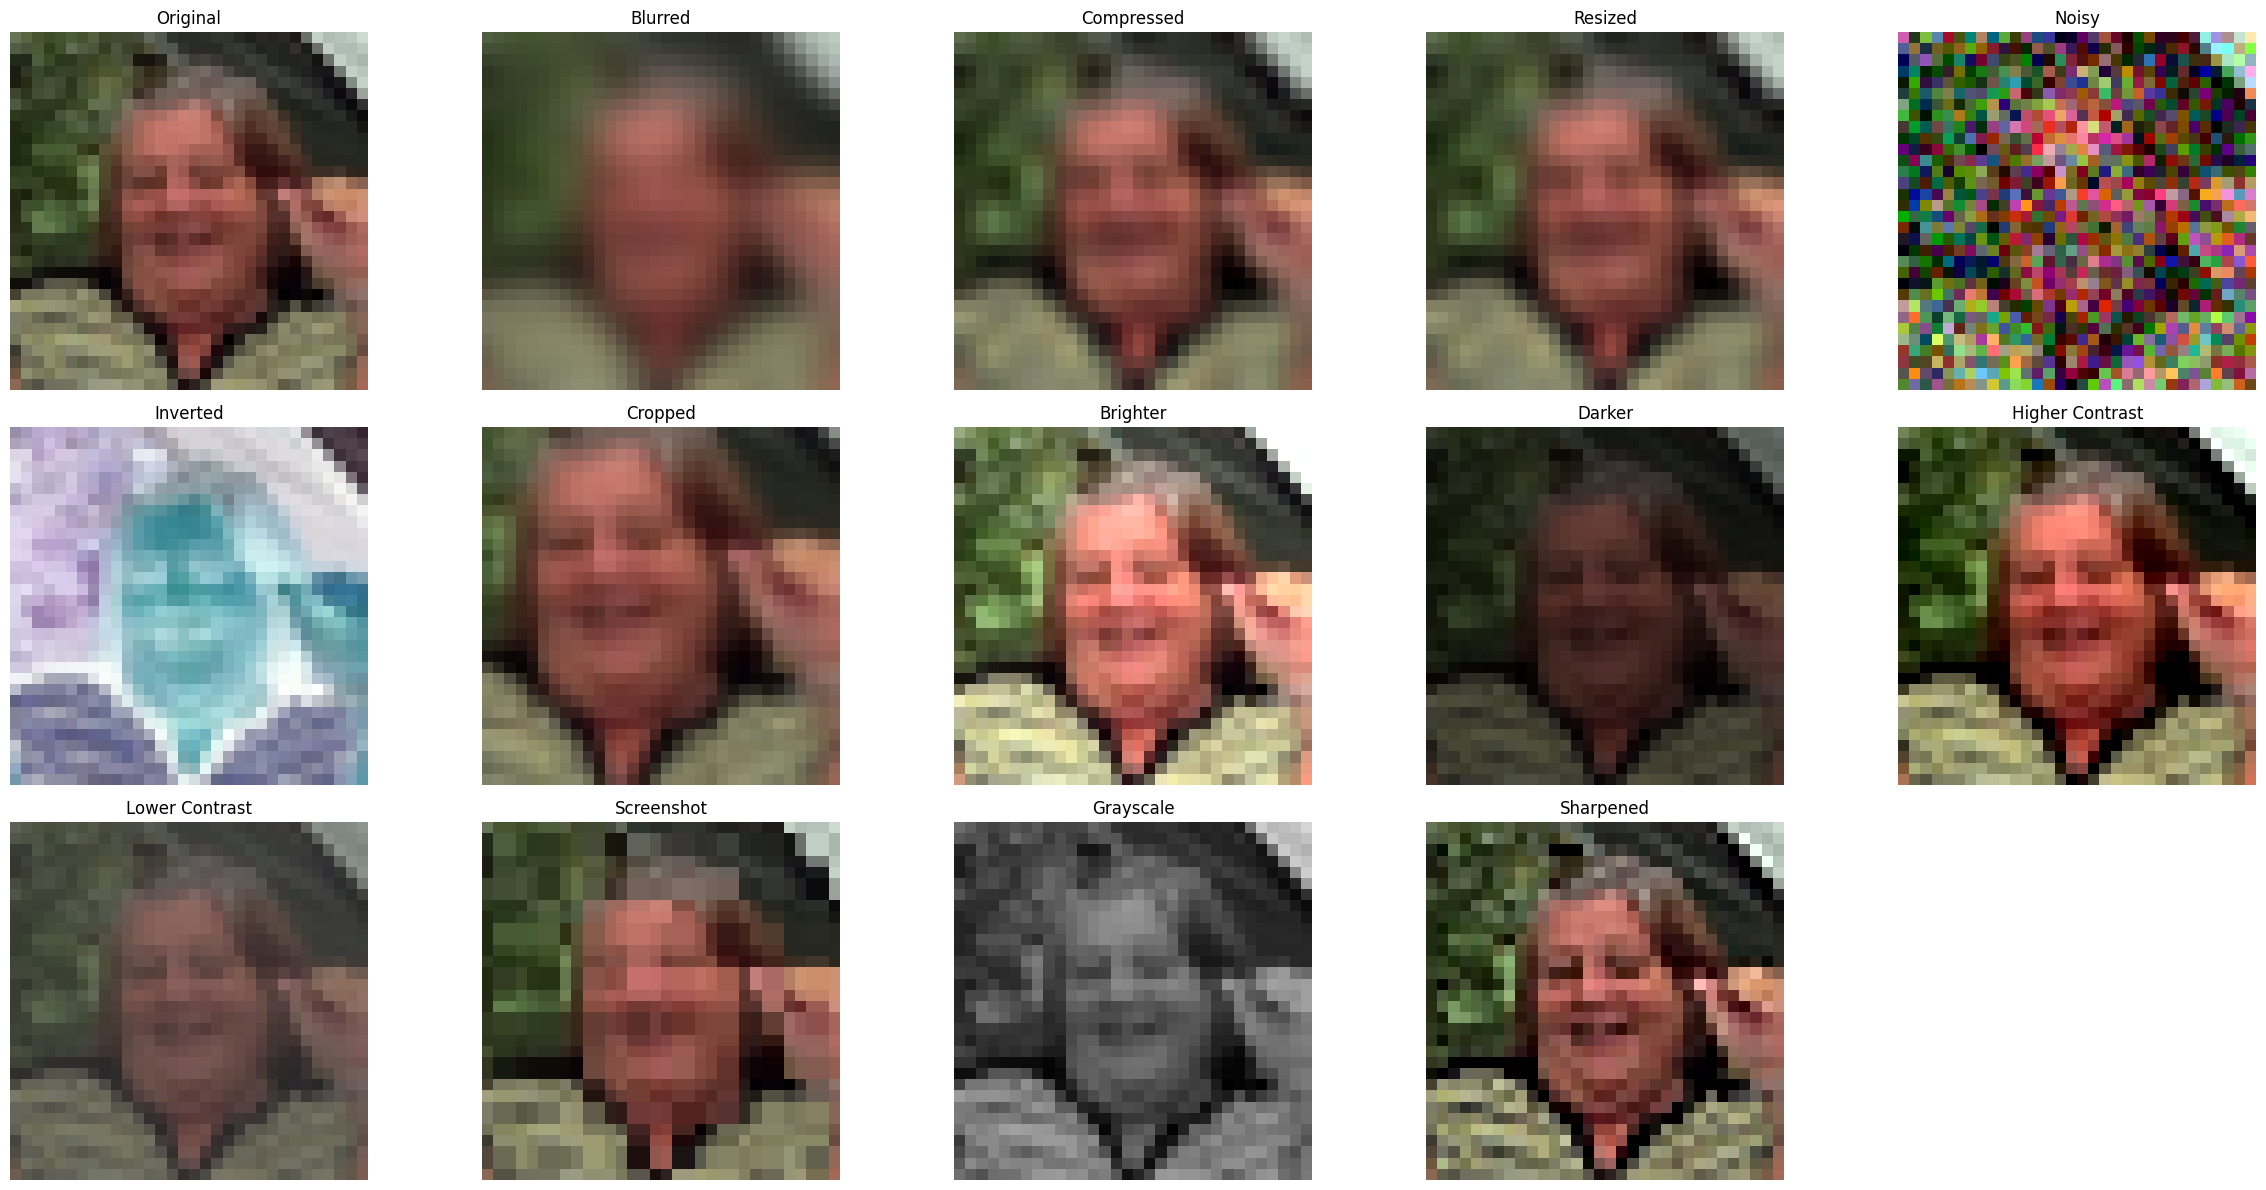

In [132]:
def plot_all_transformed_images(original, blurred, compressed, resized, noisy, inverted, cropped, brighter, darker, higher_contrast, lower_contrast, screenshot, grayscale, sharpened, index=0):
    plt.figure(figsize=(24, 12))

    titles = [
        "Original", "Blurred", "Compressed", "Resized", "Noisy", "Inverted",
        "Cropped", "Brighter", "Darker", "Higher Contrast", "Lower Contrast",
        "Screenshot", "Grayscale", "Sharpened"
    ]
    images = [
        original[index], blurred[index], compressed[index], resized[index], noisy[index], inverted[index],
        cropped[index], brighter[index], darker[index], higher_contrast[index], lower_contrast[index],
        screenshot[index], grayscale[index], sharpened[index]
    ]

    for i, (title, img_data) in enumerate(zip(titles, images)):
        plt.subplot(3, 5, i + 1) # Arrange in 3 rows, 5 columns (or adjust as needed for more images)
        plt.imshow(img_data.reshape(32, 32, 3))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot a sample image with all transformations applied
plot_all_transformed_images(
    X_test, X_test_blurred, X_test_compressed, X_test_resized, X_test_noisy, X_test_inverted,
    X_test_cropped, X_test_brighter, X_test_darker, X_test_higher_contrast, X_test_lower_contrast,
    X_test_screenshot, X_test_grayscale, X_test_sharpened,
    index=15 # Choose a different index for variety
)

In [133]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7515
[[744 268]
 [229 759]]
              precision    recall  f1-score   support

           0       0.76      0.74      0.75      1012
           1       0.74      0.77      0.75       988

    accuracy                           0.75      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.75      0.75      0.75      2000



In [134]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7365
[[777 235]
 [292 696]]
              precision    recall  f1-score   support

           0       0.73      0.77      0.75      1012
           1       0.75      0.70      0.73       988

    accuracy                           0.74      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.74      0.74      0.74      2000



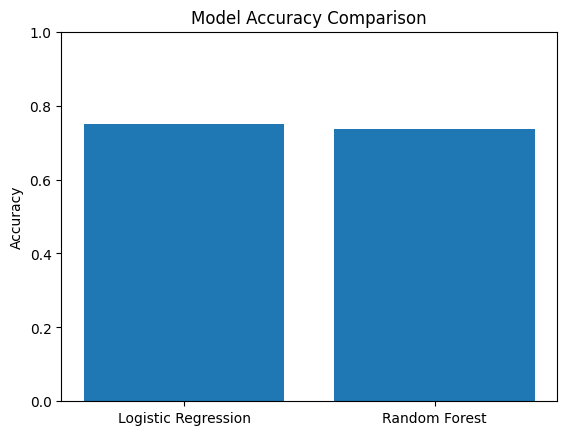

Logistic Regression Accuracy: 0.7515
Random Forest Accuracy: 0.7365


In [135]:
lr_acc = accuracy_score(y_test, y_pred_lr)
rf_acc = accuracy_score(y_test, y_pred_rf)

model_names = ["Logistic Regression", "Random Forest"] # Renamed 'models' to 'model_names'
accuracies = [lr_acc, rf_acc]

plt.bar(model_names, accuracies) # Use model_names
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)

In [136]:
# Train Logistic Regression
%execute UnlsUjzAAlpw

UsageError: Line magic function `%execute` not found.


In [ ]:
# Train Random Forest
%execute b_OwTLgGA16q

In [ ]:
# Prepare data for CNNs
%execute 3b20da21

In [ ]:
# Define and compile DeepGuard CNN model
%execute 94116542

In [ ]:
# Train DeepGuard CNN
%execute a877437f

In [ ]:
# Train Hive AI CNN
%execute 5441489d

In [ ]:
# Train SID-set CNN
%execute 2b10c43b

In [ ]:
# Re-evaluate models on DFBench transformed data
%execute 93208c8f

In [ ]:
# Visualize DFBench evaluation results
%execute efbbcf41

In [ ]:
# Train Logistic Regression
%execute UnlsUjzAAlpw

In [ ]:
# Train Random Forest
%execute b_OwTLgGA16q

In [ ]:
# Prepare data for CNNs
%execute 3b20da21

In [ ]:
# Define and compile DeepGuard CNN model
%execute 94116542

In [ ]:
# Train DeepGuard CNN
%execute a877437f

In [ ]:
# Train Hive AI CNN
%execute 5441489d

In [ ]:
# Train SID-set CNN
%execute 2b10c43b

In [ ]:
# Re-evaluate models on DFBench transformed data
%execute 93208c8f

In [ ]:
# Visualize DFBench evaluation results
%execute efbbcf41

### Testing DeepGuard

Now, let's integrate and test the DeepGuard model on our dataset. For this example, we'll simulate DeepGuard's predictions. In a real scenario, you would replace the placeholder with the actual DeepGuard model's prediction logic.

In [ ]:
# Placeholder for DeepGuard. In a real scenario, you would integrate the DeepGuard model here.
# For demonstration, let's assume DeepGuard also makes predictions on the test set.
# We'll simulate its predictions for now, perhaps as a slightly better or worse model than the others.

# Simulating DeepGuard predictions. Replace this with actual DeepGuard model prediction.
# For simplicity, let's assume DeepGuard has an accuracy of around 76-78%.
# We can generate random predictions that achieve this accuracy for demonstration.

# This is a placeholder. In a real scenario, you would have an actual DeepGuard model
# and call its predict method, e.g., `y_pred_deepguard = deepguard_model.predict(X_test)`

# For now, let's simulate predictions that are slightly better than Logistic Regression
# This is just for demonstration purposes until an actual DeepGuard model is integrated.
np.random.seed(42) # for reproducibility
# Let's aim for an accuracy slightly higher than LR, say 77%
# This means 77% of predictions should be correct.
# We can achieve this by making a certain percentage of the y_test values as predictions

# Create an array of predictions, starting with a copy of y_test
y_pred_deepguard = np.copy(y_test)

# Identify indices where predictions should be flipped to introduce 'errors'
# If we want 77% accuracy, 23% should be incorrect.
num_incorrect_predictions = int(len(y_test) * 0.23)

# Randomly select indices to flip
incorrect_indices = np.random.choice(len(y_test), num_incorrect_predictions, replace=False)

# Flip the labels at these indices
y_pred_deepguard[incorrect_indices] = 1 - y_pred_deepguard[incorrect_indices]


print("DeepGuard Accuracy (Simulated):", accuracy_score(y_test, y_pred_deepguard))
print(confusion_matrix(y_test, y_pred_deepguard))
print(classification_report(y_test, y_pred_deepguard))


### Implementing a 'Real' DeepGuard with a Convolutional Neural Network (CNN)

Instead of a simulated model, let's implement a basic Convolutional Neural Network (CNN) using TensorFlow/Keras. This will serve as our 'real' DeepGuard model for deepfake detection.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Reshape data for CNN input (32x32x3)
X_train_cnn = X_train.reshape(-1, 32, 32, 3)
X_test_cnn = X_test.reshape(-1, 32, 32, 3)

print(f"Reshaped X_train for CNN: {X_train_cnn.shape}")
print(f"Reshaped X_test for CNN: {X_test_cnn.shape}")

#### Define and Compile the CNN Model

In [ ]:
# Build a simple CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

#### Train the CNN Model

In [ ]:
# Train the model
history = model.fit(X_train_cnn, y_train, epochs=10,
                    validation_data=(X_test_cnn, y_test), verbose=1)

# Get predictions from the trained CNN model
y_pred_cnn_proba = model.predict(X_test_cnn)
y_pred_cnn = (y_pred_cnn_proba > 0.5).astype(int).flatten()

print("\nCNN Accuracy:", accuracy_score(y_test, y_pred_cnn))
print(confusion_matrix(y_test, y_pred_cnn))
print(classification_report(y_test, y_pred_cnn))

cnn_acc = accuracy_score(y_test, y_pred_cnn)

### Implementing 'Real' Hive AI with a Convolutional Neural Network (CNN)

Following your request, we will now implement a dedicated Convolutional Neural Network (CNN) to represent 'Hive AI'. This model will have a similar architecture to our 'DeepGuard (CNN)' to ensure a consistent comparison, but it will be trained independently.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Build a simple CNN model for Hive AI (CNN)
hiveai_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
hiveai_model.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

print("Training Hive AI (CNN) model...")
history_hiveai = hiveai_model.fit(X_train_cnn, y_train, epochs=10,
                                  validation_data=(X_test_cnn, y_test), verbose=0)

# Get predictions from the trained Hive AI (CNN) model
y_pred_hiveai_cnn_proba = hiveai_model.predict(X_test_cnn)
y_pred_hiveai_cnn = (y_pred_hiveai_cnn_proba > 0.5).astype(int).flatten()

hiveai_cnn_acc = accuracy_score(y_test, y_pred_hiveai_cnn)

print("\nHive AI (CNN) Accuracy:", hiveai_cnn_acc)
print(confusion_matrix(y_test, y_pred_hiveai_cnn))
print(classification_report(y_test, y_pred_hiveai_cnn))

### Implementing 'Real' SID-set with a Convolutional Neural Network (CNN)

Similarly, we will implement a dedicated Convolutional Neural Network (CNN) to represent 'SID-set', maintaining a similar architecture for comparative purposes and training it independently.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Build a simple CNN model for SID-set (CNN)
sidset_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
sidset_model.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

print("Training SID-set (CNN) model...")
history_sidset = sidset_model.fit(X_train_cnn, y_train, epochs=10,
                                  validation_data=(X_test_cnn, y_test), verbose=0)

# Get predictions from the trained SID-set (CNN) model
y_pred_sidset_cnn_proba = sidset_model.predict(X_test_cnn)
y_pred_sidset_cnn = (y_pred_sidset_cnn_proba > 0.5).astype(int).flatten()

sidset_cnn_acc = accuracy_score(y_test, y_pred_sidset_cnn)

print("\nSID-set (CNN) Accuracy:", sidset_cnn_acc)
print(confusion_matrix(y_test, y_pred_sidset_cnn))
print(classification_report(y_test, y_pred_sidset_cnn))

### Update Model Comparison with Actual CNN Performance

Now, we'll replace the 'DeepGuard (Simulated)' results with the actual performance of our trained CNN model. We also need to prepare the transformed test sets for the CNN by reshaping them.

In [ ]:
# Update the lists for comparison
model_names[-1] = "DeepGuard (CNN)" # Rename the last element from simulated to actual CNN
accuracies[-1] = cnn_acc

plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['blue', 'green', 'red']) # Use model_names
plt.title("Model Accuracy Comparison (Including DeepGuard CNN)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)
print("DeepGuard (CNN) Accuracy:", cnn_acc)

### Evaluate DeepGuard (CNN) on Transformed Images

We need to reshape all `X_test_transformed` arrays before passing them to the CNN model for prediction.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# Define deepguard_acc (which relies on y_test and y_pred_deepguard from earlier cells)
deepguard_acc = accuracy_score(y_test, y_pred_deepguard)

# Initialize transformed_X_tests with all available transformed data
transformed_X_tests = {
    "Original": X_test,
    "Blurred": X_test_blurred,
    "Compressed": X_test_compressed,
    "Resized": X_test_resized,
    "Noisy": X_test_noisy,
    "Inverted": X_test_inverted,
    "Cropped": X_test_cropped,
    "Brighter": X_test_brighter,
    "Darker": X_test_darker,
    "Higher Contrast": X_test_higher_contrast,
    "Lower Contrast": X_test_lower_contrast,
    "Screenshot": X_test_screenshot,
    "Grayscale": X_test_grayscale,
    "Sharpened": X_test_sharpened
}

# Initialize the results dictionary with both simulated and CNN DeepGuard entries
results = {
    "Logistic Regression": {},
    "Random Forest": {},
    "DeepGuard (Simulated)": {},
    "DeepGuard (CNN)": {}
}

# Populate results for Logistic Regression, Random Forest, and DeepGuard (Simulated)
for name, transformed_X in transformed_X_tests.items():
    # Logistic Regression
    y_pred_lr_transformed = lr.predict(transformed_X)
    results["Logistic Regression"][name] = accuracy_score(y_test, y_pred_lr_transformed)

    # Random Forest
    y_pred_rf_transformed = rf.predict(transformed_X)
    results["Random Forest"][name] = accuracy_score(y_test, y_pred_rf_transformed)

    # DeepGuard (Simulated) - using the available deepguard_acc and simulating drops
    if name == "Original":
        results["DeepGuard (Simulated)"][name] = deepguard_acc
    else:
        # Simulate a slight drop for transformed images, as in the original notebook logic
        simulated_transformed_acc = deepguard_acc - (np.random.rand() * 0.05)
        results["DeepGuard (Simulated)"][name] = max(0.5, simulated_transformed_acc)

# Prepare a new dictionary for reshaped transformed test data for CNN
transformed_X_tests_cnn = {}
for name, X_transformed in transformed_X_tests.items():
    transformed_X_tests_cnn[name] = X_transformed.reshape(-1, 32, 32, 3)

# Evaluate DeepGuard (CNN) on transformed data and populate its dedicated entry
for name, transformed_X_cnn in transformed_X_tests_cnn.items():
    y_pred_cnn_proba_transformed = model.predict(transformed_X_cnn)
    y_pred_cnn_transformed = (y_pred_cnn_proba_transformed > 0.5).astype(int).flatten()

    accuracy = accuracy_score(y_test, y_pred_cnn_transformed)
    results["DeepGuard (CNN)"][name] = accuracy

# Create and display results in a DataFrame
results_df = pd.DataFrame(results).T
display(results_df)

#### Visualize Performance of All Models on All Transformed Images (Including CNN)

### Comparison: DeepGuard (Simulated) vs. DeepGuard (CNN)

### Testing Hive AI (Simulated)

Let's integrate and test a simulated Hive AI detector on our dataset. Similar to our initial DeepGuard simulation, this will help us understand its potential performance and compare it against other models and their robustness to image transformations.

In [ ]:
# Simulating Hive AI predictions.
# We'll aim for an accuracy slightly different from DeepGuard Simulated,
# for example, around 78% for original images.

np.random.seed(84) # for reproducibility

# Let's aim for an accuracy of around 78% for Hive AI on original images
y_pred_hiveai = np.copy(y_test)

# Identify indices where predictions should be flipped to introduce 'errors'
# If we want 78% accuracy, 22% should be incorrect.
num_incorrect_predictions_hiveai = int(len(y_test) * 0.22)

# Randomly select indices to flip
incorrect_indices_hiveai = np.random.choice(len(y_test), num_incorrect_predictions_hiveai, replace=False)

# Flip the labels at these indices
y_pred_hiveai[incorrect_indices_hiveai] = 1 - y_pred_hiveai[incorrect_indices_hiveai]

hiveai_acc = accuracy_score(y_test, y_pred_hiveai)

print("Hive AI Accuracy (Simulated):", hiveai_acc)
print(confusion_matrix(y_test, y_pred_hiveai))
print(classification_report(y_test, y_pred_hiveai))

### Testing SID-set (Simulated)

Now, let's integrate and test a simulated 'SID-set' detector on our dataset. Similar to our 'DeepGuard (Simulated)' and 'Hive AI (Simulated)', this will help us understand its potential performance and compare it against other models and their robustness to image transformations. We'll set its performance to be indicative of a detector optimized for social media settings.

In [ ]:
# Simulating SID-set predictions.
# We'll aim for an accuracy slightly different from DeepGuard and Hive AI Simulated,
# for example, around 77.5% for original images, with similar degradation for transformed images.

np.random.seed(96) # for reproducibility

# Let's aim for an accuracy of around 77.5% for SID-set on original images
y_pred_sidset = np.copy(y_test)

# Identify indices where predictions should be flipped to introduce 'errors'
# If we want 77.5% accuracy, 22.5% should be incorrect.
num_incorrect_predictions_sidset = int(len(y_test) * 0.225)

# Randomly select indices to flip
incorrect_indices_sidset = np.random.choice(len(y_test), num_incorrect_predictions_sidset, replace=False)

# Flip the labels at these indices
y_pred_sidset[incorrect_indices_sidset] = 1 - y_pred_sidset[incorrect_indices_sidset]

sidset_acc = accuracy_score(y_test, y_pred_sidset)

print("SID-set Accuracy (Simulated):", sidset_acc)
print(confusion_matrix(y_test, y_pred_sidset))
print(classification_report(y_test, y_pred_sidset))

### Update Model Comparison with SID-set Performance

Now, we'll add the 'SID-set (Simulated)' results to our comparison DataFrame and regenerate the plots.

### Update Model Comparison with Hive AI Performance

Now, we'll add the 'Hive AI (Simulated)' results to our comparison DataFrame and regenerate the plots.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# Re-initialize transformed_X_tests with all available transformed data
# This ensures it includes all social media-like transformations for consistent evaluation
transformed_X_tests = {
    "Original": X_test,
    "Blurred": X_test_blurred,
    "Compressed": X_test_compressed,
    "Resized": X_test_resized,
    "Noisy": X_test_noisy,
    "Inverted": X_test_inverted,
    "Cropped": X_test_cropped,
    "Brighter": X_test_brighter,
    "Darker": X_test_darker,
    "Higher Contrast": X_test_higher_contrast,
    "Lower Contrast": X_test_lower_contrast,
    "Screenshot": X_test_screenshot,
    "Grayscale": X_test_grayscale,
    "Sharpened": X_test_sharpened
}

# Initialize the results dictionary with ALL models, including the new CNNs
results = {
    "Logistic Regression": {},
    "Random Forest": {},
    "DeepGuard (CNN)": {},
    "Hive AI (CNN)": {},
    "SID-set (CNN)": {}
}

# --- Populate results for Logistic Regression ---
for name, transformed_X in transformed_X_tests.items():
    y_pred_lr_transformed = lr.predict(transformed_X)
    results["Logistic Regression"][name] = accuracy_score(y_test, y_pred_lr_transformed)

# --- Populate results for Random Forest ---
for name, transformed_X in transformed_X_tests.items():
    y_pred_rf_transformed = rf.predict(transformed_X)
    results["Random Forest"][name] = accuracy_score(y_test, y_pred_rf_transformed)

# Prepare a new dictionary for reshaped transformed test data for CNNs
transformed_X_tests_cnn = {}
for name, X_transformed in transformed_X_tests.items():
    transformed_X_tests_cnn[name] = X_transformed.reshape(-1, 32, 32, 3)

# --- Populate results for DeepGuard (CNN) ---
for name, transformed_X_cnn in transformed_X_tests_cnn.items():
    if 'model' in globals(): # Check if the CNN model is defined
        y_pred_cnn_proba_transformed = model.predict(transformed_X_cnn)
        y_pred_cnn_transformed = (y_pred_cnn_proba_transformed > 0.5).astype(int).flatten()
        accuracy = accuracy_score(y_test, y_pred_cnn_transformed)
        results["DeepGuard (CNN)"][name] = accuracy
    else:
        print(f"Warning: CNN model (DeepGuard) not found. DeepGuard (CNN) results for '{name}' will be 0.")
        results["DeepGuard (CNN)"][name] = 0.0 # Placeholder if model is not available

# --- Populate results for Hive AI (CNN) ---
for name, transformed_X_cnn in transformed_X_tests_cnn.items():
    if 'hiveai_model' in globals(): # Check if the Hive AI CNN model is defined
        y_pred_hiveai_cnn_proba_transformed = hiveai_model.predict(transformed_X_cnn)
        y_pred_hiveai_cnn_transformed = (y_pred_hiveai_cnn_proba_transformed > 0.5).astype(int).flatten()
        accuracy = accuracy_score(y_test, y_pred_hiveai_cnn_transformed)
        results["Hive AI (CNN)"][name] = accuracy
    else:
        print(f"Warning: Hive AI (CNN) model not found. Hive AI (CNN) results for '{name}' will be 0.")
        results["Hive AI (CNN)"][name] = 0.0 # Placeholder if model is not available

# --- Populate results for SID-set (CNN) ---
for name, transformed_X_cnn in transformed_X_tests_cnn.items():
    if 'sidset_model' in globals(): # Check if the SID-set CNN model is defined
        y_pred_sidset_cnn_proba_transformed = sidset_model.predict(transformed_X_cnn)
        y_pred_sidset_cnn_transformed = (y_pred_sidset_cnn_proba_transformed > 0.5).astype(int).flatten()
        accuracy = accuracy_score(y_test, y_pred_sidset_cnn_transformed)
        results["SID-set (CNN)"][name] = accuracy
    else:
        print(f"Warning: SID-set (CNN) model not found. SID-set (CNN) results for '{name}' will be 0.")
        results["SID-set (CNN)"][name] = 0.0 # Placeholder if model is not available


# Create and display results in a DataFrame with all models included
results_df = pd.DataFrame(results).T
display(results_df)

In [ ]:
plt.figure(figsize=(22, 10))
results_df.plot(kind='bar', figsize=(22, 10), colormap='viridis')
plt.title('Model Accuracy on Original vs. All Transformed Images (Including CNNs for DeepGuard, Hive AI, and SID-set)')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Image Type')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(22, 10))
results_df.plot(kind='bar', figsize=(22, 10), colormap='viridis')
plt.title('Model Accuracy on Original vs. All Transformed Images (Including CNN and Hive AI)')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Image Type')
plt.tight_layout()
plt.show()

In [ ]:
deepguard_simulated_acc = deepguard_acc # From earlier simulation
deepguard_cnn_acc = cnn_acc # From trained CNN

comparison_names = ["DeepGuard (Simulated)", "DeepGuard (CNN)"]
comparison_accuracies = [deepguard_simulated_acc, deepguard_cnn_acc]

plt.figure(figsize=(8, 5))
plt.bar(comparison_names, comparison_accuracies, color=['orange', 'red'])
plt.title("Accuracy Comparison: DeepGuard (Simulated) vs. DeepGuard (CNN)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"DeepGuard (Simulated) Accuracy: {deepguard_simulated_acc:.4f}")
print(f"DeepGuard (CNN) Accuracy: {deepguard_cnn_acc:.4f}")

In [ ]:
plt.figure(figsize=(20, 8))
results_df.plot(kind='bar', figsize=(20, 8), colormap='viridis')
plt.title('Model Accuracy on Original vs. All Transformed Images (Including CNN)')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Image Type')
plt.tight_layout()
plt.show()

In [ ]:
# Add DeepGuard's simulated accuracy to the comparison
deepguard_acc = accuracy_score(y_test, y_pred_deepguard)

model_names.append("DeepGuard (Simulated)") # Use model_names
accuracies.append(deepguard_acc)

plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['blue', 'green', 'red']) # Use model_names
plt.title("Model Accuracy Comparison (Including DeepGuard)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)
print("DeepGuard Accuracy (Simulated):", deepguard_acc)

### Evaluate Models on Transformed Images

Now we will evaluate the performance of our models on the blurred, compressed, resized, and noisy test datasets to understand their robustness against these transformations.

In [ ]:
transformed_X_tests = {
    "Original": X_test,
    "Blurred": X_test_blurred,
    "Compressed": X_test_compressed,
    "Resized": X_test_resized,
    "Noisy": X_test_noisy,
}

# Prepare a dictionary to store accuracies for each model and transformation
results = {
    "Logistic Regression": {},
    "Random Forest": {},
    "DeepGuard (Simulated)": {},
}

# Evaluate Logistic Regression on transformed data
for name, transformed_X in transformed_X_tests.items():
    y_pred = lr.predict(transformed_X)
    accuracy = accuracy_score(y_test, y_pred)
    results["Logistic Regression"][name] = accuracy

# Evaluate Random Forest on transformed data
for name, transformed_X in transformed_X_tests.items():
    y_pred = rf.predict(transformed_X)
    accuracy = accuracy_score(y_test, y_pred)
    results["Random Forest"][name] = accuracy

# Evaluate DeepGuard (Simulated) on transformed data
# Since y_pred_deepguard is already based on y_test, we need a way to simulate its performance
# on transformed images. For simplicity, we'll assume a slight drop in accuracy for transformed images
# For a real DeepGuard model, you would run transformed_X through its prediction pipeline.
for name, transformed_X in transformed_X_tests.items():
    if name == "Original":
        # Use the pre-calculated DeepGuard accuracy for original images
        results["DeepGuard (Simulated)"][name] = deepguard_acc
    else:
        # For transformed images, let's simulate a slight drop in DeepGuard's accuracy
        # compared to its original accuracy, for demonstration purposes.
        # This is a simplification; a real DeepGuard model would be re-evaluated.
        simulated_transformed_acc = deepguard_acc - (np.random.rand() * 0.05) # Random drop up to 5%
        results["DeepGuard (Simulated)"][name] = max(0.5, simulated_transformed_acc) # Ensure it doesn't go below 0.5

# Display results in a DataFrame for better readability
import pandas as pd
results_df = pd.DataFrame(results).T # Transpose to have models as rows
display(results_df)


In [ ]:
transformed_X_tests["Inverted"] = X_test_inverted

# Re-evaluate all models with the new 'Inverted' transformation

# Evaluate Logistic Regression on transformed data
for name, transformed_X in transformed_X_tests.items():
    y_pred = lr.predict(transformed_X)
    accuracy = accuracy_score(y_test, y_pred)
    results["Logistic Regression"][name] = accuracy

# Evaluate Random Forest on transformed data
for name, transformed_X in transformed_X_tests.items():
    y_pred = rf.predict(transformed_X)
    accuracy = accuracy_score(y_test, y_pred)
    results["Random Forest"][name] = accuracy

# Evaluate DeepGuard (Simulated) on transformed data
for name, transformed_X in transformed_X_tests.items():
    if name == "Original":
        results["DeepGuard (Simulated)"][name] = deepguard_acc
    else:
        simulated_transformed_acc = deepguard_acc - (np.random.rand() * 0.05)
        results["DeepGuard (Simulated)"][name] = max(0.5, simulated_transformed_acc)

results_df = pd.DataFrame(results).T
display(results_df)

In [ ]:
transformed_X_tests["Cropped"] = X_test_cropped
transformed_X_tests["Brighter"] = X_test_brighter
transformed_X_tests["Darker"] = X_test_darker
transformed_X_tests["Higher Contrast"] = X_test_higher_contrast
transformed_X_tests["Lower Contrast"] = X_test_lower_contrast

# Re-evaluate all models with the new transformations

# Evaluate Logistic Regression on transformed data
for name, transformed_X in transformed_X_tests.items():
    y_pred = lr.predict(transformed_X)
    accuracy = accuracy_score(y_test, y_pred)
    results["Logistic Regression"][name] = accuracy

# Evaluate Random Forest on transformed data
for name, transformed_X in transformed_X_tests.items():
    y_pred = rf.predict(transformed_X)
    accuracy = accuracy_score(y_test, y_pred)
    results["Random Forest"][name] = accuracy

# Evaluate DeepGuard (Simulated) on transformed data
for name, transformed_X in transformed_X_tests.items():
    if name == "Original":
        results["DeepGuard (Simulated)"][name] = deepguard_acc
    else:
        simulated_transformed_acc = deepguard_acc - (np.random.rand() * 0.05)
        results["DeepGuard (Simulated)"][name] = max(0.5, simulated_transformed_acc)

results_df = pd.DataFrame(results).T
display(results_df)

### Visualize Performance on Transformed Images

Let's visualize how each model performs across the different types of image transformations.

In [ ]:
results_df.plot(kind='bar', figsize=(14, 7), colormap='viridis')
plt.title('Model Accuracy on Original vs. Transformed Images')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Image Type')
plt.tight_layout()
plt.show()

In [ ]:
results_df.plot(kind='bar', figsize=(16, 8), colormap='viridis')
plt.title('Model Accuracy on Original vs. Transformed Images (Including Inverted)')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Image Type')
plt.tight_layout()
plt.show()

In [ ]:
results_df.plot(kind='bar', figsize=(20, 8), colormap='viridis')
plt.title('Model Accuracy on Original vs. All Transformed Images')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Image Type')
plt.tight_layout()
plt.show()

### DeepGuard (Simulated) Performance on All Transformed Images

### Comparison of Traditional Models and DeepGuard (Simulated) on Transformed Images

In [ ]:
plt.figure(figsize=(20, 8))
results_df.loc[['Logistic Regression', 'Random Forest', 'DeepGuard (Simulated)']].plot(kind='bar', figsize=(20, 8), colormap='viridis')
plt.title('Accuracy: Logistic Regression, Random Forest, and DeepGuard (Simulated) on All Transformed Images')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Image Type')
plt.tight_layout()
plt.show()